In [1]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import colors
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.ticker as ticker
from matplotlib.ticker import FormatStrFormatter
from matplotlib import cm
from scipy.signal import savgol_filter
from pprint import pprint
import pickle
from matplotlib.lines import Line2D
from functions import *
import h5py
import numpy as np
from rand_funcs import *
import copy

import h5py
import warnings


def load_obj(name):
    with open('bestfits/' + name + '.pkl', 'rb') as f:
        obj = pickle.load(f)
        print(name+':')
        if 'varied' in name:
            for z in obj.keys():
                print('z = '+z)
                p1, p2, p3, p4, p5, p6 = obj[z]['Transition point'], obj[z]['Pre-disk slope'],\
                                         obj[z]['Pre-disk normalization'], obj[z]['Pre-disk sigma'],\
                                         obj[z]['Post-disk sigma'], obj[z]['Post-disk normalization']
                print(z+' & $10^{'+str(p1)+'}$ & '+str(p2)+' & $10^{'+str(p3)+'}$ & '+str(p4)+' & '+str(p5)+' & '+str(p6)+' \\')
                print('\n')
        else:
            p1, p2, p3, p4, p5, p6 = obj['Transition point'], obj['Pre-disk slope'],\
                                     obj['Pre-disk normalization'], obj['Pre-disk sigma'],\
                                     obj['Post-disk sigma'], obj['Post-disk normalization']
            print('ALL & $10^{'+str(p1)+'}$ & '+str(p2)+' & $10^{'+str(p3)+'}$ & '+str(p4)+' & '+str(p5)+' & '+str(p6)+' \\')
            print('\n')
        return obj

### Load best fit values and organize them.

In [2]:
def organize_set_varied_dicts(set_dict, varied_dict):
    fixed_params = {'Mscrit':set_dict['Transition point'], 'presig':set_dict['Pre-disk sigma'],\
                'postsig':set_dict['Post-disk sigma'], 'preslope': set_dict['Pre-disk slope'],\
                'Mbhnorm':set_dict['Pre-disk normalization'], 'postnorm':set_dict['Post-disk normalization']} #allowing no parameters to vary

    varied_params = {'Mscrit':[varied_dict[v]['Transition point'] for v in varied_dict],\
              'presig':[varied_dict[v]['Pre-disk sigma'] for v in varied_dict],\
              'postsig':[varied_dict[v]['Post-disk sigma'] for v in varied_dict],\
              'preslope':[varied_dict[v]['Pre-disk slope'] for v in varied_dict],\
              'Mbhnorm':[varied_dict[v]['Pre-disk normalization'] for v in varied_dict],\
              'postnorm':[varied_dict[v]['Post-disk normalization'] for v in varied_dict]}
    
    return fixed_params, varied_params

fixed_fiducial, varied_fiducial = load_obj('fixed_2P'), load_obj('varied_2P')
fixed_fiducial_a1, varied_fiducial_a1 = load_obj('fixed_2P_a1'), load_obj('varied_2P_a1')
fixed_L, varied_L = load_obj('fixed_L'), load_obj('varied_L')

fixed_paramsF, varied_paramsF = organize_set_varied_dicts(fixed_fiducial, varied_fiducial)
fixed_paramsF_a1, varied_paramsF_a1 = organize_set_varied_dicts(fixed_fiducial_a1, varied_fiducial_a1)
fixed_paramsL, varied_paramsL = organize_set_varied_dicts(fixed_L, varied_L)


fixed_2P:
ALL & $10^{10.666666666666666}$ & 0.9 & $10^{1.83875}$ & 2.3458333333333337 & 1.3250000000000002 & -2.3333333333333335 \


varied_2P:
z = 0.5
0.5 & $10^{10.666666666666666}$ & 0.7000000000000001 & $10^{2.005}$ & 2.3458333333333337 & 1.529166666666667 & -2.3333333333333335 \


z = 1.0
1.0 & $10^{10.833333333333332}$ & 1.0 & $10^{1.83875}$ & 2.141666666666667 & 1.1208333333333336 & -2.166666666666667 \


z = 2.0
2.0 & $10^{10.833333333333332}$ & 1.2000000000000002 & $10^{1.83875}$ & 2.141666666666667 & 1.1208333333333336 & -2.25 \


z = 3.0
3.0 & $10^{10.666666666666666}$ & 1.7000000000000002 & $10^{1.0075}$ & 2.3458333333333337 & 1.1208333333333336 & -2.3333333333333335 \


z = 4.0
4.0 & $10^{10.5}$ & 1.4000000000000001 & $10^{1.50625}$ & 2.5500000000000003 & 1.3250000000000002 & -2.416666666666667 \


fixed_2P_a1:
ALL & $10^{10.666666666666666}$ & 1.0 & $10^{1.83875}$ & 2.3458333333333337 & 1.3250000000000002 & -2.3333333333333335 \


varied_2P_a1:
z = 0.5
0.5 & $10^{10.83333

# Stellar Mass - SMBH Mass Relation (FIGURE 1)

FileNotFoundError: [Errno 2] Unable to open file (unable to open file: name = 'sim_data/galdata_h206.hdf5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

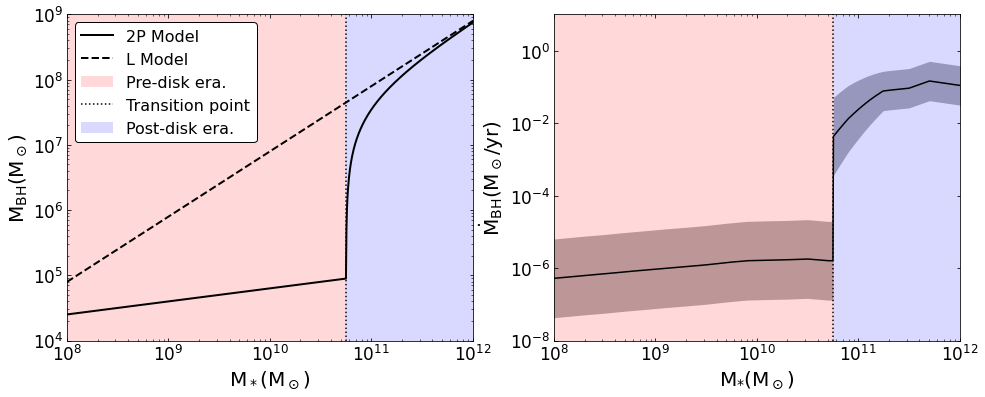

In [7]:
plt.close('all')

#### creating the SM-BH relation plots with varying parameters
fig = plt.figure(figsize=(16,6))
gs = gridspec.GridSpec(1, 2)

pre, post, SIG_lnMs, Ms_crit, b = 2.5, 1.25, 0.7, 10.75, 0.005
slope_low, norm_from_local, norm_of_local = .2, 2.7, -3.1

L = np.linspace(5,18,200)
z = 4.0
norm = [11, 8.2]
tw, tl = 1, 5
legfs = 10
legtfs = 10
tfs = 9
xlim = (10**8, 10**12)
ylim = (10**4,10**9)

ax = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])

qlf = QLF(z, b)
qlf.get_Mbh(Ms_crit, slope_low, norm_from_local, approx_local=True, norm_local = 11+norm_of_local)
Mbh = qlf.BHBins
Mstar = qlf.StellBins

l1, = ax.plot(10**Mstar, 10**Mbh, c='k', label = '2P Model', lw=2)
ax.set_xlabel(r'$\rmM_*(M_\odot)$', fontsize = 20)
ax.set_ylabel(r'$\rmM_{BH}(M_\odot)$',fontsize = 20)
l2, = ax.plot(10**Mstar, 10**(Mstar+norm_of_local), c='k', linestyle='dashed', label='L Model', lw=2)
h1 = ax.axvspan(10**Mstar[0], 10**Ms_crit, color='r', alpha = 0.15, label='Pre-disk era.', lw=0)
l3 = ax.axvline(10**Ms_crit, color = 'k', linestyle='dotted', label=r'Transition point', lw=1.5)
h2 = ax.axvspan(10**Ms_crit, 10**Mstar[-1], color='b', alpha = 0.15, label='Post-disk era.', lw=0)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.tick_params(direction='in', which='both', right = True, labelsize = 17, top = True)
legend1 = ax.legend(handles = [l1, l2, h1, l3, h2], fontsize = 16, loc='upper left', framealpha=1, edgecolor = 'k')

# pre, post, Ms_crit, b = 2.5, 1.25, 10.5, 0.005
# slope_low, norm_from_local, norm_of_local = .2, 2.7, -2.95

qlf = QLF(z, 0.005)
qlf.get_Mbh(Ms_crit, slope_low, norm_from_local, norm_local = 11+norm_of_local)
qlf.get_dNdlnL(L, [pre, post])

Mdot_mu_sig = qlf.Mdot_mu_sig
BHBins = qlf.BHBins
StellBins = qlf.StellBins

h1 = ax1.axvspan(1e7, 10**Ms_crit, color='r', alpha = 0.15, label='Pre-disk era.', lw=0)
l3 = ax1.axvline(10**Ms_crit, color = 'k', linestyle='dotted', label=r'Transition point', lw=1.5)
h2 = ax1.axvspan(10**Ms_crit, 1e12, color='b', alpha = 0.15, label='Post-disk era.', lw=0)
l1, ax1.plot(10**StellBins, np.e**np.array(Mdot_mu_sig[:, 0])*3.154e7/2e33, c='k', label='2P Model')
y1 = np.e**(Mdot_mu_sig[:, 0] + Mdot_mu_sig[:, 1])*3.154e7/2e33
y2 = np.e**(Mdot_mu_sig[:, 0] - Mdot_mu_sig[:, 1])*3.154e7/2e33
ax1.fill_between(10**StellBins, y1, y2, alpha = 0.3, color='k', lw=0)
fl = ax1.axhline(1e-9, ls = 'dashed', c='k', label = 'Floor')    


# legend = ax1.legend(handles = [l1, h1, l3, h2], fontsize = 16, framealpha=1, edgecolor = 'k', loc='upper left')
# plt.setp(legend.get_title(), fontsize=16)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlim(xlim)
ax1.set_ylim([1e-8, 1e1])
ax1.tick_params(direction='in', which='both', right = True, labelsize = 17, top = True)
ax1.set_ylabel(r'$\rm\dot{M}_{BH} (M_\odot/yr)$',fontsize=20)
ax1.set_xlabel(r'$\rmM_{*} (M_\odot)$',fontsize=20)

sims = ['h206', 'h29', 'h113', 'h2']
asims = ['A1', 'A2', 'A4', 'A8']
sim_lines = []
for sim, asim, ls in zip(sims, asims, ['solid', 'dashed', 'dotted', 'dashdot']):
    f = h5py.File('sim_data/galdata_'+sim+'.hdf5','r')
    redshift = f['redshift'][:]
    StarMass = f['0.1Rvir']['StarMass'][:]
    f.close()
    monoStarMass = []
    monoredshift = []
    for i, m in enumerate(StarMass):
        if i != 0:
            try:
                if (StarMass[i] > monoStarMass[-1]) or (StarMass[i] == 0.0) or (StarMass[i] == -np.inf):
                    pass
                else:
                    monoStarMass.append(StarMass[i])
                    monoredshift.append(redshift[i])
            except:
                if (StarMass[i] > StarMass[i-1]) or (StarMass[i] == 0.0) or (StarMass[i] == -np.inf):
                    pass
                else: 
                    monoStarMass.append(StarMass[i])
                    monoredshift.append(redshift[i])


    f = h5py.File('sim_data/bh_history_'+sim+'_HR.hdf5','r')
    Mbh_torque = f['Mbh_torque'][:]
    Mdot_torque = f['Mdot_torque'][:]
    a = f['a'][:]
    dt = f['dt'][:]
    f.close()   
    dtcumulative = np.cumsum(dt)
         
    ztemp = 1.0/a - 1.0
    extendedStarMass = np.zeros(len(Mdot_torque))
    for i in range(len(monoStarMass)):
        if i != 0:
            logmonoStarMass = np.log10(monoStarMass)
            imatch1 = np.argmin(np.abs(monoredshift[i-1]-ztemp))
            imatch2 = np.argmin(np.abs(monoredshift[i]-ztemp))
            partialStarMass = 10**np.interp(dtcumulative[imatch1:imatch2], [dtcumulative[imatch1],dtcumulative[imatch2]],\
                                            [logmonoStarMass[i-1], logmonoStarMass[i]])
            extendedStarMass[imatch1:imatch2] = partialStarMass

    plotMstar = extendedStarMass[extendedStarMass != 0]
    plotMdotbh = Mdot_torque[extendedStarMass != 0]
    plotMdotbh[plotMdotbh < 1e-9] = 1e-9
    plotMbh = Mbh_torque[extendedStarMass != 0]
    
    if asim == 'A2':
        ax1.plot(plotMstar, plotMdotbh, c='gray', zorder = 0, ls=ls) 
    
    siml, = ax.plot(plotMstar, plotMbh, label=asim, c='gray', ls = ls)
    sim_lines.append(siml)
    
legend2 = ax.legend(handles = sim_lines, fontsize = 14, loc='lower right', framealpha=1, edgecolor = 'k', title='FIRE Sim.')
plt.setp(legend2.get_title(), fontsize=14)
ax.add_artist(legend1)


plt.tight_layout(rect=[0, 0, 1, 1])
plt.savefig('plots/FINAL_paper_plots/SMBH_SM_relation_mk2.pdf')

# Best Fit Values for Fixed and Varied Fits (FIGURE 5)

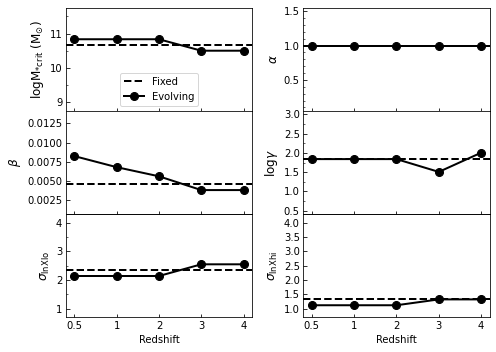

In [17]:
plt.close('all')

param_labels = {'Mscrit':r'$\log \rmM_{*crit}$ $(\rmM_{\odot})$',\
         'preslope':r'$\alpha$',\
         'Mbhnorm':r'$\log \gamma$',\
         'presig':r'$\sigma_{\ln{\rmXlo}}$',\
         'postsig':r'$\sigma_{\ln{\rmXhi}}$',\
         'postnorm':r'$\beta$'}

inds = {'Mscrit':[0,0],\
         'preslope':[0,1],\
         'Mbhnorm':[1,1],\
         'presig':[2,0],\
         'postsig':[2,1],\
         'postnorm':[1,0]}

ylim = {'Mscrit':(8.75, 11.75),\
         'preslope':(0.05, 1.55),\
         'Mbhnorm':(0.41, 3.09),\
         'presig':(0.7, 4.3),\
         'postsig':(0.7, 4.3),\
         'postnorm':(10**-3.15, 10**-1.85)}

tick_loc = {'Mscrit':[1.0, 0.5],\
         'preslope':[0.5, 0.1],\
         'Mbhnorm':[0.5, 0.25],\
         'presig':[1.0, 0.5],\
         'postsig':[0.5, 0.5],\
         'postnorm':[0.0025, 0.01]}

size = 100
marker = 'o-'
offset = 0.075
dupoff = 0.15

redshifts = ['0.5', '1', '2', '3', '4']
    
fig = plt.figure(figsize=(7,5))
gs = gridspec.GridSpec(3, 2)

for key in varied_paramsF_a1.keys():
    ax = fig.add_subplot(gs[inds[key][0], inds[key][1]])
    ax.set_ylim(ylim[key])
    ax.set_ylabel(param_labels[key], fontsize=12)
    if 'sig' in key:
        ax.set_ylabel(param_labels[key], fontsize=12)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(tick_loc[key][0]))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(tick_loc[key][1]))
    if key == 'postnorm':
        n = ax.axhline(10**fixed_paramsF_a1[key], c='k', linestyle='dashed', lw = 2)
        a, = ax.plot(redshifts, [10**i for i in varied_paramsF_a1[key]], '-o', c='k', ms = 8, lw = 2)
    else:
        n = ax.axhline(fixed_paramsF_a1[key], c='k', linestyle='dashed', lw = 2)
        a, = ax.plot(redshifts, varied_paramsF_a1[key], '-o', c='k', ms = 8, lw = 2)
    ax.tick_params(axis='both', which='both', direction='in')
    if key != 'presig' and key != 'postsig':
        plt.setp(ax.get_xticklabels(), visible=False)
    else:
        ax.set_xlabel('Redshift')
    if key == 'Mscrit':
        ax.legend(handles=[n,a], labels=['Fixed', 'Evolving'], loc='lower center',fontsize = 10)
        

    
plt.tight_layout()
plt.subplots_adjust(hspace = .001)

plt.savefig('paper_plots/bestfit-params_QLF.pdf')



# Free Parameter Effects (FIGURE 3)

Mscrit: 9.666666666666666
Mscrit: 10.666666666666666
Mscrit: 11.666666666666666
preslope: 0.5
preslope: 1.0
preslope: 1.5
Mbhnorm: 1.33875
Mbhnorm: 1.83875
Mbhnorm: 2.33875
postnorm: -2.5333333333333337
postnorm: -2.3333333333333335
postnorm: -2.1333333333333333
presig: 1.8458333333333337
presig: 2.3458333333333337
presig: 2.8458333333333337
postsig: 0.8250000000000002
postsig: 1.3250000000000002
postsig: 1.8250000000000002


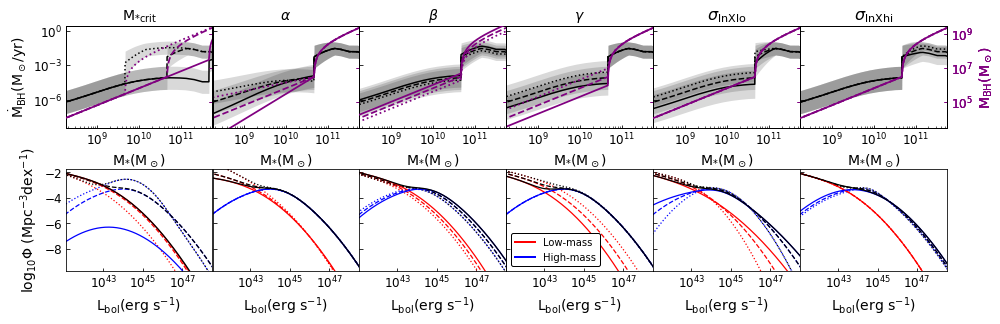

In [31]:
plt.close('all')

fig = plt.figure(figsize=(14,4.75))
gs = gridspec.GridSpec(2, 6)

def plotMbhMstar(qlf, c, ls, ax):
    color = 'purple'
    ax.plot(10**qlf.StellBins, 10**qlf.BHBins, lw=1.75, c=color, ls=ls, zorder = 5)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.axis([10**8.25, 10**11.75, 10**3.5,10**9.5])
    ax.tick_params(axis = 'y', direction='in', which='both', labelsize = 12, color = color,labelcolor=color)
    ax.set_ylabel(r'$\rmM_{BH}(M_\odot)$',fontsize = 14, color = color)
    
def plotMdotbhMstar(qlf, c, ls, ax):
    Mdot_mu_sig = qlf.Mdot_mu_sig
    ax.plot(10**qlf.StellBins, np.e**np.array(Mdot_mu_sig[:, 0])*3.154e7/2e33, c=c, lw=1.5, ls=ls, zorder=1)
    y1 = np.e**(Mdot_mu_sig[:, 0] + Mdot_mu_sig[:, 1])*3.154e7/2e33
    y2 = np.e**(Mdot_mu_sig[:, 0] - Mdot_mu_sig[:, 1])*3.154e7/2e33
    ax.fill_between(10**qlf.StellBins, y1, y2, alpha = 0.15, color=c, lw=0, zorder = 0)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.tick_params(direction='in', which='both', top = False, labelsize = 12, axis='both')
    ax.axis([10**8.25, 10**11.75, 10**-8.5, 10**0.5])
    ax.set_ylabel(r'$\rm\dot{M}_{BH} (M_\odot/yr)$',fontsize=14)
    

inds = {'Mscrit':[1,0],\
         'preslope':[1,1],\
         'Mbhnorm':[1,3],\
         'postnorm':[1,2],\
         'presig':[1,4],\
         'postsig':[1,5]}

plottype = {'Mscrit':'MbhMstar',\
         'preslope':'MbhMstar',\
         'Mbhnorm':'MbhMstar',\
         'presig':'MdotbhMstar',\
         'postsig':'MdotbhMstar',\
         'postnorm':'MbhMstar'}

leg_titles = {'Mscrit':r'$\rmM_{*crit}$',\
         'preslope':r'$\alpha$',\
         'Mbhnorm':r'$\gamma$',\
         'presig':r'$\sigma_{\ln{\rmXlo}}$',\
         'postsig':r'$\sigma_{\ln{\rmXhi}}$',\
         'postnorm':r'$\beta$'}

leg_format = {'Mscrit':[r'$10^{', '}$ M$_{\odot}$'],\
         'preslope':['', ''],\
         'Mbhnorm':['$10^{', '}$ M$_{\odot}$'],\
         'presig':['', ' dex'],\
         'postsig':['', ' dex'],\
         'postnorm':['', '']}

param_adj = {'Mscrit':1.0,\
         'preslope':0.5,\
         'Mbhnorm':0.5,\
         'presig':0.5,\
         'postsig':0.5,\
         'postnorm':0.2}

param_colors = {'Mscrit':'el',\
         'preslope':'e',\
         'Mbhnorm':'e',\
         'presig':'el',\
         'postsig':'l',\
         'postnorm':'el'}

lines = ['dotted','dashed','solid']

color_list = ['g', 'b', 'orange']

def qlf_data(Mscrit, presig, postsig, preslope, Mbhnorm, postnorm):
    qlf = QLF(z, 0.005)
    qlf.get_Mbh(Mscrit, slope_low = preslope, norm_from_local = Mbhnorm, norm_local = 11+postnorm)
    qlf.get_dNdlnL(lums, [presig, postsig])
    return qlf

lums = np.linspace(5,18,200)
lumsp = 10**lums*3.8e33
z = 1.0

### loop over different parameters
for key in inds.keys():
    
    c = param_colors[key]

    ax = fig.add_subplot(gs[inds[key][0], inds[key][1]])
    ax2 = fig.add_subplot(gs[0, inds[key][1]])

    for i, ls, c2 in zip([-1, 0, 1], lines, color_list):

        params_temp = fixed_paramsF_a1.copy()
        params_temp[key] += param_adj[key]*i
        print(key+':',params_temp[key])
        qlf = qlf_data(**params_temp)

        ### find the late and early lines
        totearly = np.sum(qlf.intvals[:,qlf.pre], axis = 1)
        totlate = np.sum(qlf.intvals[:,qlf.post], axis = 1)

        #         if 'e' in c:
        ax.plot(lumsp, np.log10(np.asarray(totearly) * np.log(10)), c='r',lw=1.25, ls=ls)
#         if 'l' in c:
        ax.plot(lumsp, np.log10(np.asarray(totlate) * np.log(10)), c='b',lw=1.25, ls=ls) 
        
        ### plot
        ax.plot(lumsp, np.log10(qlf.dNdlogL), c='k',lw=1.25, ls=ls)
            
        plotMdotbhMstar(qlf, 'k', ls, ax2)
            
#         if plottype[key] == 'MbhMstar':
        ax2i = ax2.twinx()  # instantiate a second axes that shares the same x-axis
        plotMbhMstar(qlf, 'k', ls, ax2i)
        if key != 'postsig':
            ax2i.set_ylabel('')
            plt.setp(ax2i.get_yticklabels(), visible=False)

            
    dens, stanave, stanab, stanb, _ = Shen_fit_uncer(z, lums)
    
    ax.axis([10**7.5*3.8e33,10**14.95*3.8e33,-9.75,-1.75])
    ax.set_ylabel(r'$\log_{10} \Phi$ $(\rmMpc^{-3} dex^{-1}$)', fontsize=14) #'\left(\rmMpc^{-3} \log_{10} \left[L_{bol}\right]^{-1}\right)\right]$', fontsize =9)
    
    if inds[key][1] != 0:
        ax.set_ylabel('')
        ax2.set_ylabel('')
    
    if inds[key][1] != 0:
        plt.setp(ax.get_yticklabels(), visible=False)
        plt.setp(ax2.get_yticklabels(), visible=False)
        
    ax.set_xlabel(r'$\rmL_{bol} (erg\ s^{-1})$', fontsize=14)
    ax2.set_xlabel(r'$\rmM_{*} (M_\odot)$',fontsize=14)
    
    if key == 'postsig' or key == 'presig':
        ax2.set_title(leg_titles[key], fontsize=16)
    else:
        ax2.set_title(leg_titles[key], fontsize=14)
        

    ax.set_xscale('log')
    ax.tick_params(axis='both', which='both', labelsize=12, direction='in', right = False, top = False)


    legend_elements = [Line2D([0], [0], color='k', ls='dotted',lw=2, label='Smaller'),
                       Line2D([0], [0], color='k', ls='dashed',lw=2, label=''),
                       Line2D([0], [0], color='k', ls='solid',lw=2, label='Larger')]

#     if key == 'postsig':
#         ax.legend(handles=legend_elements, loc='lower left', fontsize=10, frameon=True, framealpha = 1, edgecolor = 'k')
        
    legend_elements = [Line2D([0], [0], color='r', ls='solid',lw=2, label='Low-mass'),
                   Line2D([0], [0], color='b', ls='solid',lw=2, label='High-mass')]
    if key == 'Mbhnorm':
        ax.legend(handles=legend_elements, loc='lower left', fontsize=10, frameon=True, framealpha = 1, edgecolor = 'k')


plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.subplots_adjust(hspace = .4, wspace = .0001)
plt.savefig('paper_plots/free_param_effects.pdf')


# Best Fit QLFs (FIGURE 4)

## 6 param version


{'z=0.5': 177, 'z=1.0': 180, 'z=2.0': 183, 'z=3.0': 154, 'z=4.0': 91, 'fixed': 785}


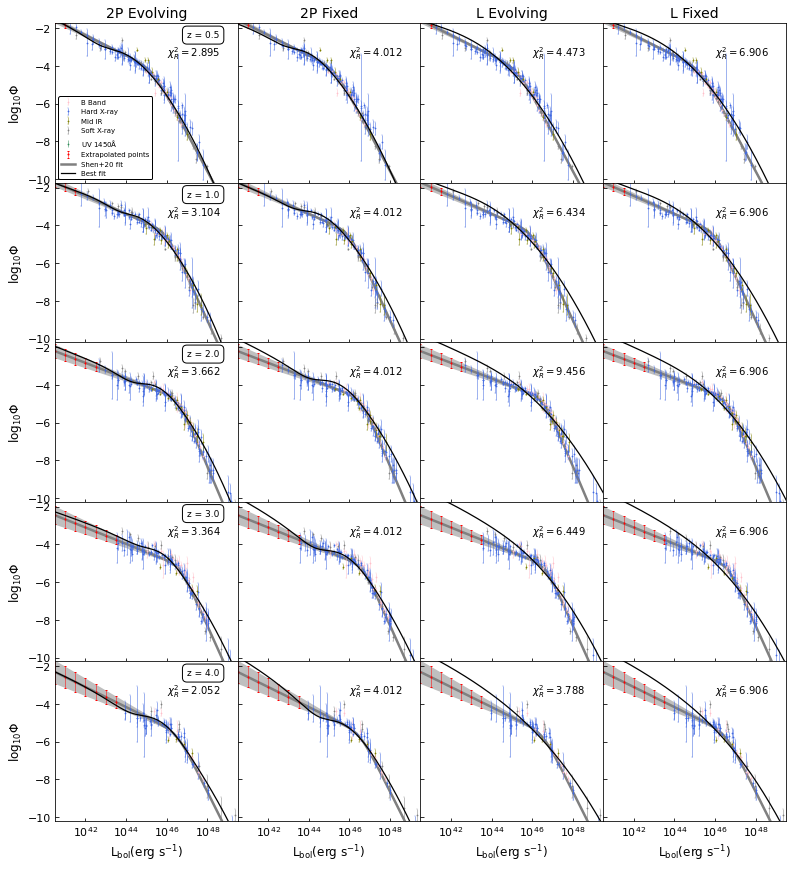

In [3]:
plt.close('all')

fig = plt.figure(figsize=(11,12))
gs = gridspec.GridSpec(5, 4)


colors = list(cm.viridis(np.arange(5) / 5) ) 
redshifts = [0.5, 1.0, 2.0, 3.0, 4.0]
lums = np.linspace(6,16,200)
lumsp = 10**lums*3.8e33

lw = 1.25

num_of_points = {'z=0.5':0,'z=1.0':0,'z=2.0':0,'z=3.0':0,'z=4.0':0, 'fixed':0}

fobs = h5py.File("SHEN_obs_collect.h5py", "r")
for z in [0.5,1.0,2.0,3.0,4.0]:
    for band in fobs["z="+str(z)]:
        index = "z="+str(z)+"/"+band
        x = fobs[index]['x'][:]
        y = fobs[index]['y'][:]
        num_of_points['z='+str(z)] += len(x)
        num_of_points['fixed'] += len(x)
        
    xtot = []
    ya = []
    yaerr = []
    for band in fobs["z="+str(z)]:
        index = "z="+str(z)+"/"+band
        xtot.extend(fobs[index]['x'][:]) ##log10 of bolometric L in erg/s
        ya.extend(fobs[index]['y'][:]) ##log10 of QLF
        yaerr.extend(fobs[index]['yerr'][:]) ##error on that

    xobscut = min(np.asarray(xtot))
    xphan = np.linspace(40, 44, 9)
    if round(xobscut) < xobscut:
        xphan = xphan[xphan <= round(xobscut)]
    else:
        xphan = xphan[xphan < round(xobscut)]
    num_of_points['z='+str(z)] += len(xphan)
    num_of_points['fixed'] += len(xphan)
        
        
fobs.close()
print(num_of_points)

def plot_obs(ax, phantom = False):
    objs = []
    labels = []
    colors = {'B-Band':'pink', 'UV-1450A':'seagreen', 'Hard-X':'royalblue', 'Soft-X':'grey', 'Mid-IR':'olive'}
    cleanlabel = {'B-Band':'B Band', 'UV-1450A':r'UV 1450$\rm\AA$', 'Hard-X':'Hard X-ray', 'Soft-X':'Soft X-ray', 'Mid-IR':'Mid IR'}

    fobs = h5py.File("SHEN_obs_collect.h5py", "r")
    for band in fobs["z="+str(z)]:
        index = "z="+str(z)+"/"+band
        x = fobs[index]['x'][:]
        y = fobs[index]['y'][:]
        xerr = fobs[index]['xerr'][:]
        yerr = fobs[index]['yerr'][:]
        xerrcor = np.zeros((2,len(xerr)))
        xerrcor[1,:] = 10**(x + xerr) - 10**x
        xerrcor[0,:] = 10**x - 10**(x - xerr)

        b = ax.errorbar(10**x, y, yerr = yerr, c=colors[band], fmt = 'o', fillstyle='none', capsize=0.75, ms=.75, lw=0.5, capthick=0.25, zorder=2, alpha = 1)
        objs.append(b)
        labels.append(cleanlabel[band])
    fobs.close()
    
    if phantom:
        xtot = []
        ya = []
        yaerr = []
        fobs = h5py.File("SHEN_obs_collect.h5py", "r")
        for band in fobs["z="+str(z)]:
            index = "z="+str(z)+"/"+band
            xtot.extend(fobs[index]['x'][:]) ##log10 of bolometric L in erg/s
            ya.extend(fobs[index]['y'][:]) ##log10 of QLF
            yaerr.extend(fobs[index]['yerr'][:]) ##error on that
        fobs.close()

        xobscut = min(np.asarray(xtot))
        xphan = np.linspace(40, 44, 9)
        if round(xobscut) < xobscut:
            xphan = xphan[xphan <= round(xobscut)]
        else:
            xphan = xphan[xphan < round(xobscut)]
        yphan, yphanerr, _, _, _ = Shen_fit_uncer(z, np.log10(10**xphan/3.8e33))

        p = ax.errorbar(10**xphan, yphan, yerr = yphanerr, c='r', fmt = 'o', fillstyle='none', capsize=1, ms=1.0, lw=0.5, zorder=2)
        objs.append(p)
        labels.append('Extrapolated points')

    return objs, labels

def plot_SHEN(ax):
    dens, stanave, stanab, stanb, _ = Shen_fit_uncer(z, lums)
    sqlf, = ax.plot(lumsp, dens, lw=2.5, linestyle='solid', c='gray', zorder=1)
    ax.fill_between(lumsp, dens + stanave, dens - stanave, color = 'gray', alpha = 0.5, zorder = 0, lw = 0)
    label = 'Shen+20 fit'
    
    return sqlf, label

def format_QLF_ax(ax):
    ax.tick_params(axis='both', which='both', labelsize=11, direction='in')
    ax.tick_params(axis='both', which='both', labelsize=11, direction='in')
    ax.axis([10**40.5,10**49.5,-10.2,-1.75])
    ax.set_xscale('log')
    
def format_MsMbh_ax(ax):
    ax.tick_params(axis='both', which='both', labelsize=11, direction='in')
    ax.tick_params(axis='both', which='both', labelsize=11, direction='in')
    ax.set_xlim([10**8,10**12.5])
    ax.set_ylim([10**5, 10**10.5])
    ax.set_yscale('log')
    ax.set_xscale('log')
    
def get_QLF(lums, z, params):
    
    Mscrit = params['Transition point']
    preslope = params['Pre-disk slope']
    Mbhnorm = params['Pre-disk normalization']
    postnorm = params['Post-disk normalization']
    presig = params['Pre-disk sigma']
    postsig = params['Post-disk sigma']
    
    qlf = QLF(z, 0.005)
    qlf.get_Mbh(Mscrit, preslope, Mbhnorm, approx_local=True, norm_local = 11+postnorm)
    qlf.get_dNdlnL(lums, [presig, postsig])
    
    return qlf

zlabels = []
zobjs = []
for (i, z), c in zip(enumerate(redshifts), colors):
    
    axz1 = fig.add_subplot(gs[i, 0])
    axz2 = fig.add_subplot(gs[i, 1])
    axz3 = fig.add_subplot(gs[i, 2])
    axz4 = fig.add_subplot(gs[i, 3])
    
    #### 2P vary all
    qlf = get_QLF(lums, z, varied_fiducial[str(z)])
    fl, = axz1.plot(lumsp, np.log10(qlf.dNdlogL), lw=lw, c='k', zorder=10)
    axz1.text(1e46, -3.5, r'$\chi^2_R = $'+str(varied_fiducial[str(z)]['Chi2 value']/num_of_points["z="+str(z)])[0:5])
    
      
    #### 2P vary none
    qlf = get_QLF(lums, z, fixed_fiducial)
    axz2.plot(lumsp, np.log10(qlf.dNdlogL), lw=lw, c='k', zorder=10)
    axz2.text(1e46, -3.5, r'$\chi^2_R = $'+str(fixed_fiducial['Chi2 value']/num_of_points['fixed'])[0:5])
    
    #### L vary all
    qlf = get_QLF(lums, z, varied_L[str(z)])
    axz3.plot(lumsp, np.log10(qlf.dNdlogL), lw=lw, c='k', zorder=10)
#     ax3.plot(10**qlf.StellBins, 10**qlf.BHBins, lw=lw, c=c)
    axz3.text(1e46, -3.5, r'$\chi^2_R = $'+str(varied_L[str(z)]['Chi2 value']/num_of_points["z="+str(z)])[0:5])

    
    #### L vary none
    qlf = get_QLF(lums, z, fixed_L)
    axz4.plot(lumsp, np.log10(qlf.dNdlogL), lw=lw, c='k', zorder=10)  
#     ax4.plot(10**qlf.StellBins, 10**qlf.BHBins,lw=lw, c=c)
    axz4.text(1e46, -3.5, r'$\chi^2_R = $'+str(fixed_L['Chi2 value']/num_of_points['fixed'])[0:5])

    
    
    objs, labels = plot_obs(axz1, phantom = True)
    plot_obs(axz2, phantom = True)
    plot_obs(axz3, phantom = True)
    plot_obs(axz4, phantom = True)
    
    sqlf, slabel = plot_SHEN(axz1)
    plot_SHEN(axz2)
    plot_SHEN(axz3)
    plot_SHEN(axz4)
    
    objs.append(sqlf)
    labels.append(slabel)
    objs.append(fl)
    labels.append("Best fit")
    
    if z == 0.5:
        axz1.legend(handles = objs, labels = labels, fontsize = 7, loc='lower left', facecolor='white', framealpha=1, edgecolor='k')
        axz1.set_title('2P Evolving', fontsize = 14)
        axz2.set_title('2P Fixed', fontsize = 14)
        axz3.set_title('L Evolving', fontsize = 14)
        axz4.set_title('L Fixed', fontsize= 14)
    if z == 4.0:
        axz1.set_xlabel(r'$\rmL_{bol} (erg\ s^{-1})$', fontsize=12)
        axz2.set_xlabel(r'$\rmL_{bol} (erg\ s^{-1})$', fontsize=12)
        axz3.set_xlabel(r'$\rmL_{bol} (erg\ s^{-1})$', fontsize=12)
        axz4.set_xlabel(r'$\rmL_{bol} (erg\ s^{-1})$', fontsize=12)
    else:
        plt.setp(axz1.get_xticklabels(), visible=False)
        plt.setp(axz2.get_xticklabels(), visible=False)
        plt.setp(axz3.get_xticklabels(), visible=False)
        plt.setp(axz4.get_xticklabels(), visible=False)
        
    axz1.set_ylabel(r'$\log_{10} \Phi$', fontsize=12)

    format_QLF_ax(axz1)
    format_QLF_ax(axz2)
    format_QLF_ax(axz3)
    format_QLF_ax(axz4)
    plt.setp(axz2.get_yticklabels(), visible=False)
    plt.setp(axz3.get_yticklabels(), visible=False)
    plt.setp(axz4.get_yticklabels(), visible=False)
    
    axz1.text(1e47, -2.5, 'z = '+str(z), fontsize=9, bbox=dict(facecolor='white', alpha=1, edgecolor='k', boxstyle='round,pad=0.5'))

    
gs.tight_layout(fig, pad = 0.0, rect=[0.005, 0.005, 0.995, 0.995])
gs.update(wspace=0.0)
gs.update(hspace=0.0)


plt.savefig('paper_plots/figure4_alpha0-2.pdf')

## alpha = 1 version


{'z=0.5': 177, 'z=1.0': 180, 'z=2.0': 183, 'z=3.0': 154, 'z=4.0': 91, 'fixed': 785}


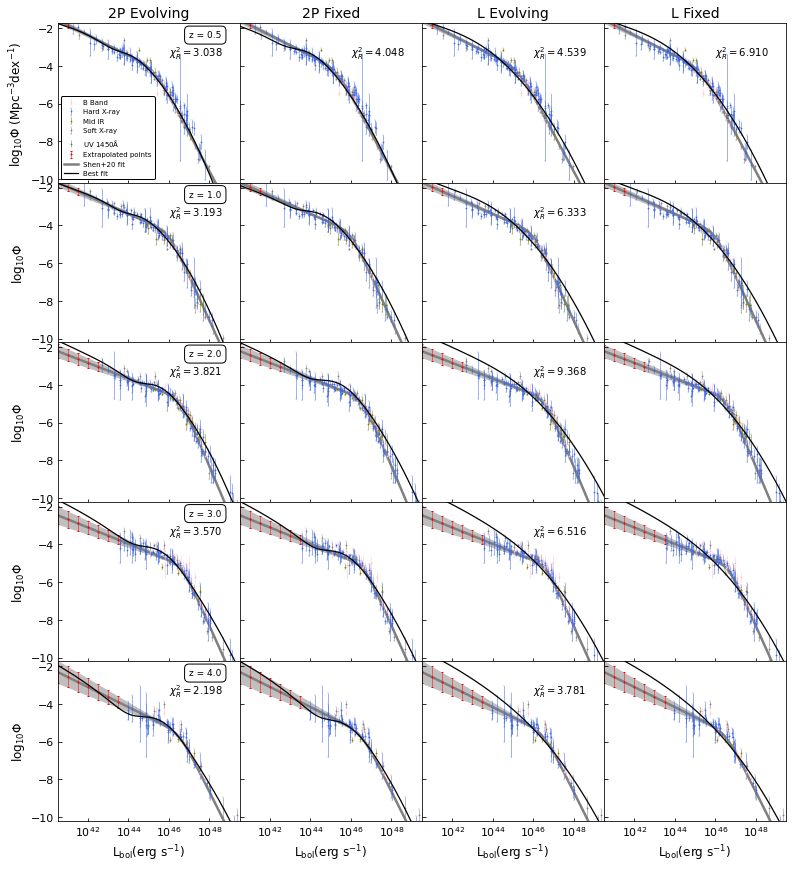

In [33]:
plt.close('all')

fig = plt.figure(figsize=(11,12))
gs = gridspec.GridSpec(5, 4)


colors = list(cm.viridis(np.arange(5) / 5) ) 
redshifts = [0.5, 1.0, 2.0, 3.0, 4.0]
lums = np.linspace(6,16,200)
lumsp = 10**lums*3.8e33

lw = 1.25

num_of_points = {'z=0.5':0,'z=1.0':0,'z=2.0':0,'z=3.0':0,'z=4.0':0, 'fixed':0}

fobs = h5py.File("SHEN_obs_collect.h5py", "r")
for z in [0.5,1.0,2.0,3.0,4.0]:
    for band in fobs["z="+str(z)]:
        index = "z="+str(z)+"/"+band
        x = fobs[index]['x'][:]
        y = fobs[index]['y'][:]
        num_of_points['z='+str(z)] += len(x)
        num_of_points['fixed'] += len(x)
        
    xtot = []
    ya = []
    yaerr = []
    for band in fobs["z="+str(z)]:
        index = "z="+str(z)+"/"+band
        xtot.extend(fobs[index]['x'][:]) ##log10 of bolometric L in erg/s
        ya.extend(fobs[index]['y'][:]) ##log10 of QLF
        yaerr.extend(fobs[index]['yerr'][:]) ##error on that

    xobscut = min(np.asarray(xtot))
    xphan = np.linspace(40, 44, 9)
    if round(xobscut) < xobscut:
        xphan = xphan[xphan <= round(xobscut)]
    else:
        xphan = xphan[xphan < round(xobscut)]
    num_of_points['z='+str(z)] += len(xphan)
    num_of_points['fixed'] += len(xphan)
    
fobs.close()
print(num_of_points)

def plot_obs(ax, phantom = False):
    objs = []
    labels = []
    colors = {'B-Band':'pink', 'UV-1450A':'seagreen', 'Hard-X':'royalblue', 'Soft-X':'grey', 'Mid-IR':'olive'}
    cleanlabel = {'B-Band':'B Band', 'UV-1450A':r'UV 1450$\rm\AA$', 'Hard-X':'Hard X-ray', 'Soft-X':'Soft X-ray', 'Mid-IR':'Mid IR'}

    fobs = h5py.File("SHEN_obs_collect.h5py", "r")
    for band in fobs["z="+str(z)]:
        index = "z="+str(z)+"/"+band
        x = fobs[index]['x'][:]
        y = fobs[index]['y'][:]
        xerr = fobs[index]['xerr'][:]
        yerr = fobs[index]['yerr'][:]
        xerrcor = np.zeros((2,len(xerr)))
        xerrcor[1,:] = 10**(x + xerr) - 10**x
        xerrcor[0,:] = 10**x - 10**(x - xerr)

        b = ax.errorbar(10**x, y, yerr = yerr, c=colors[band], fmt = 'o', fillstyle='none', capsize=0.75, ms=.75, lw=0.5, capthick=0.25, zorder=2, alpha = 1)
        objs.append(b)
        labels.append(cleanlabel[band])
    fobs.close()
    
    if phantom:
        xtot = []
        ya = []
        yaerr = []
        fobs = h5py.File("SHEN_obs_collect.h5py", "r")
        for band in fobs["z="+str(z)]:
            index = "z="+str(z)+"/"+band
            xtot.extend(fobs[index]['x'][:]) ##log10 of bolometric L in erg/s
            ya.extend(fobs[index]['y'][:]) ##log10 of QLF
            yaerr.extend(fobs[index]['yerr'][:]) ##error on that
        fobs.close()

        xobscut = min(np.asarray(xtot))
        xphan = np.linspace(40, 44, 9)
        if round(xobscut) < xobscut:
            xphan = xphan[xphan <= round(xobscut)]
        else:
            xphan = xphan[xphan < round(xobscut)]
        yphan, yphanerr, _, _, _ = Shen_fit_uncer(z, np.log10(10**xphan/3.8e33))

        p = ax.errorbar(10**xphan, yphan, yerr = yphanerr, c='r', fmt = 'o', fillstyle='none', capsize=1, ms=1.0, lw=0.5, zorder=2)
        objs.append(p)
        labels.append('Extrapolated points')

    return objs, labels

def plot_SHEN(ax):
    dens, stanave, stanab, stanb, _ = Shen_fit_uncer(z, lums)
    sqlf, = ax.plot(lumsp, dens, lw=2.5, linestyle='solid', c='gray', zorder=1)
    ax.fill_between(lumsp, dens + stanave, dens - stanave, color = 'gray', alpha = 0.5, zorder = 0, lw = 0)
    label = 'Shen+20 fit'
    
    return sqlf, label

def format_QLF_ax(ax):
    ax.tick_params(axis='both', which='both', labelsize=11, direction='in')
    ax.tick_params(axis='both', which='both', labelsize=11, direction='in')
    ax.axis([10**40.5,10**49.5,-10.2,-1.75])
    ax.set_xscale('log')
    
def format_MsMbh_ax(ax):
    ax.tick_params(axis='both', which='both', labelsize=11, direction='in')
    ax.tick_params(axis='both', which='both', labelsize=11, direction='in')
    ax.set_xlim([10**8,10**12.5])
    ax.set_ylim([10**5, 10**10.5])
    ax.set_yscale('log')
    ax.set_xscale('log')
    
def get_QLF(lums, z, params):
    
    Mscrit = params['Transition point']
    preslope = params['Pre-disk slope']
    Mbhnorm = params['Pre-disk normalization']
    postnorm = params['Post-disk normalization']
    presig = params['Pre-disk sigma']
    postsig = params['Post-disk sigma']
    
    qlf = QLF(z, 0.005)
    qlf.get_Mbh(Mscrit, preslope, Mbhnorm, approx_local=True, norm_local = 11+postnorm)
    qlf.get_dNdlnL(lums, [presig, postsig])
    
    return qlf

zlabels = []
zobjs = []
for (i, z), c in zip(enumerate(redshifts), colors):
    
    axz1 = fig.add_subplot(gs[i, 0])
    axz2 = fig.add_subplot(gs[i, 1])
    axz3 = fig.add_subplot(gs[i, 2])
    axz4 = fig.add_subplot(gs[i, 3])
    
    #### 2P vary all
    qlf = get_QLF(lums, z, varied_fiducial_a1[str(z)])
    fl, = axz1.plot(lumsp, np.log10(qlf.dNdlogL), lw=lw, c='k', zorder=10)
    axz1.text(1e46, -3.5, r'$\chi^2_R = $'+str(varied_fiducial_a1[str(z)]['Chi2 value']/(num_of_points["z="+str(z)]-5))[0:5])
    
      
    #### 2P vary none
    qlf = get_QLF(lums, z, fixed_fiducial_a1)
    axz2.plot(lumsp, np.log10(qlf.dNdlogL), lw=lw, c='k', zorder=10)
    if i == 0:
        axz2.text(1e46, -3.5, r'$\chi^2_R = $'+str(fixed_fiducial_a1['Chi2 value']/(num_of_points['fixed']-5))[0:5])
    
    #### L vary all
    qlf = get_QLF(lums, z, varied_L[str(z)])
    axz3.plot(lumsp, np.log10(qlf.dNdlogL), lw=lw, c='k', zorder=10)
#     ax3.plot(10**qlf.StellBins, 10**qlf.BHBins, lw=lw, c=c)
    axz3.text(1e46, -3.5, r'$\chi^2_R = $'+str(varied_L[str(z)]['Chi2 value']/(num_of_points["z="+str(z)]-2))[0:5])

    
    #### L vary none
    qlf = get_QLF(lums, z, fixed_L)
    axz4.plot(lumsp, np.log10(qlf.dNdlogL), lw=lw, c='k', zorder=10)  
#     ax4.plot(10**qlf.StellBins, 10**qlf.BHBins,lw=lw, c=c)
    if i == 0:
        axz4.text(1e46, -3.5, r'$\chi^2_R = $'+str(fixed_L['Chi2 value']/(num_of_points['fixed']-2))[0:5])

    
    
    objs, labels = plot_obs(axz1, phantom = True)
    plot_obs(axz2, phantom = True)
    plot_obs(axz3, phantom = True)
    plot_obs(axz4, phantom = True)
    
    sqlf, slabel = plot_SHEN(axz1)
    plot_SHEN(axz2)
    plot_SHEN(axz3)
    plot_SHEN(axz4)
    
    objs.append(sqlf)
    labels.append(slabel)
    objs.append(fl)
    labels.append("Best fit")
    
    if z == 0.5:
        axz1.legend(handles = objs, labels = labels, fontsize = 7, loc='lower left', facecolor='white', framealpha=1, edgecolor='k')
        axz1.set_title('2P Evolving', fontsize = 14)
        axz2.set_title('2P Fixed', fontsize = 14)
        axz3.set_title('L Evolving', fontsize = 14)
        axz4.set_title('L Fixed', fontsize= 14)
    if z == 4.0:
        axz1.set_xlabel(r'$\rmL_{bol} (erg\ s^{-1})$', fontsize=12)
        axz2.set_xlabel(r'$\rmL_{bol} (erg\ s^{-1})$', fontsize=12)
        axz3.set_xlabel(r'$\rmL_{bol} (erg\ s^{-1})$', fontsize=12)
        axz4.set_xlabel(r'$\rmL_{bol} (erg\ s^{-1})$', fontsize=12)
    else:
        plt.setp(axz1.get_xticklabels(), visible=False)
        plt.setp(axz2.get_xticklabels(), visible=False)
        plt.setp(axz3.get_xticklabels(), visible=False)
        plt.setp(axz4.get_xticklabels(), visible=False)
        
    if z == 0.5:
        axz1.set_ylabel(r'$\log_{10} \Phi$ $(\rmMpc^{-3} dex^{-1}$)', fontsize=12)
    else:
        axz1.set_ylabel(r'$\log_{10} \Phi$', fontsize=12)


    format_QLF_ax(axz1)
    format_QLF_ax(axz2)
    format_QLF_ax(axz3)
    format_QLF_ax(axz4)
    plt.setp(axz2.get_yticklabels(), visible=False)
    plt.setp(axz3.get_yticklabels(), visible=False)
    plt.setp(axz4.get_yticklabels(), visible=False)
    
    axz1.text(1e47, -2.5, 'z = '+str(z), fontsize=9, bbox=dict(facecolor='white', alpha=1, edgecolor='k', boxstyle='round,pad=0.5'))

    
gs.tight_layout(fig, pad = 0.0, rect=[0.005, 0.005, 0.995, 0.995])
gs.update(wspace=0.0)
gs.update(hspace=0.0)


plt.savefig('paper_plots/figure4_alpha1.pdf')

# Representative QLF Result/Construction (FIGURE 2)

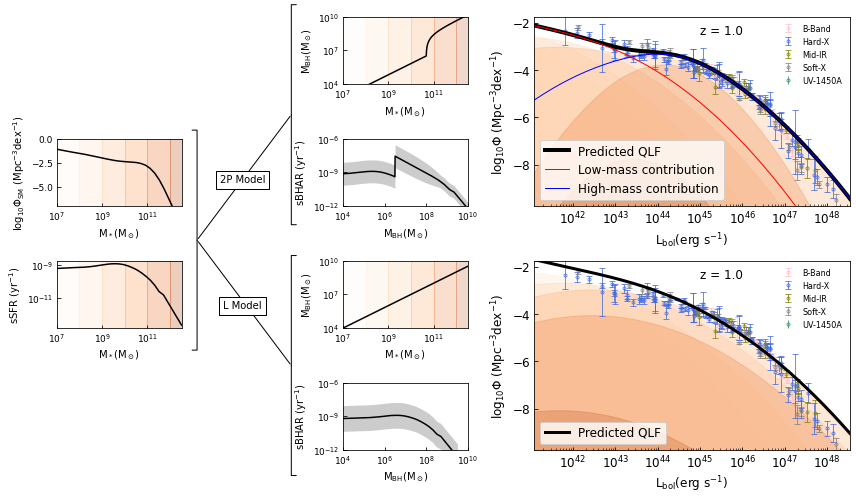

In [34]:
plt.close('all')

bins = 0.001
z = 1.0
set_params = fixed_paramsF_a1
lums = np.linspace(5,18,200)
lumsp = 10**lums*3.8e33

fig = plt.figure(figsize=(12,7))
gs = gridspec.GridSpec(8, 9)


ax = fig.add_subplot(gs[0:4, 5:])

pars = 6
cs = list(cm.Oranges(np.arange(pars) / pars) ) 
cs2 = list(cm.Blues(np.arange(pars) / pars) ) 



qlf = QLF(z, bins)
qlf.get_Mbh(set_params['Mscrit'], set_params['preslope'], set_params['Mbhnorm'],norm_local = 11+set_params['postnorm'])
qlf.get_dNdlnL(lums, [set_params['presig'], set_params['postsig']])

CRIT_IND = np.argmin(np.abs(qlf.StellBins - set_params['Mscrit']))

dens, stanave, stanab, stanb, _ = Shen_fit_uncer(z, lums)
# ax.plot(lumsp, dens,c='grey', label='Shen et al. (2020)', lw=3, zorder=0)

# ax.axvline(10**8.95*3.8e33, c='k', linestyle='dotted', lw= 1)
ax.plot(lumsp, np.log10(qlf.dNdlogL), c='k', label = 'Predicted QLF', ls='solid', lw=4)   

totpre = np.sum(qlf.intvals[:,qlf.pre], axis = 1)
totpost = np.sum(qlf.intvals[:,qlf.post], axis = 1)
ax.plot(lumsp, np.log10(np.asarray(totpre) * np.log(10)), c='r', ls='solid', label='Low-mass contribution', lw=1)
ax.plot(lumsp, np.log10(np.asarray(totpost) * np.log(10)), c='b', ls='solid', label='High-mass contribution', lw=1) 

mass_begin = 7
temp = np.zeros(len(lumsp))
for m, n, c in zip(qlf.StellBins, range(pars), cs):
    temp = temp*0
    for dens in np.transpose(qlf.intvals)[((qlf.StellBins >= mass_begin)&(qlf.StellBins<= mass_begin+1)),:]:
        temp += dens
    ax.fill_between(lumsp, -10, np.log10(temp * np.log(10)), color = c, alpha = 0.2)
    mass_begin += 1  
    
    
    

ax.axis([10**7.5*3.8e33,10**14.95*3.8e33,-9.75,-1.75])
ax.set_xlabel(r'$\rmL_{bol} (erg\ s^{-1})$', fontsize=12)
# ax.set_ylabel(r'$\log_{10} \Phi \left(\rmMpc^{-3} \log_{10} \left[L_{bol}\right]^{-1}\right)\right]$', fontsize=12) #'\left(\rmMpc^{-3} \log_{10} \left[L_{bol}\right]^{-1}\right)\right]$', fontsize =9)
ax.set_ylabel(r'$\log_{10} \Phi$ $(\rmMpc^{-3} dex^{-1}$)', fontsize =12)
ax.text(10**45,-2.5,'z = 1.0', fontsize = 12)
ax.set_xscale('log')
ax.tick_params(axis='both', which='both', labelsize=12, direction='in')  
legend = ax.legend(fontsize = 12, loc ='lower left')

bands = []
labels = []
band_colors = {'B-Band':'pink', 'UV-1450A':'seagreen', 'Hard-X':'royalblue', 'Soft-X':'gray', 'Mid-IR':'olive'}

fobs = h5py.File("SHEN_obs_collect.h5py", "r") 
for band in fobs["z="+str(z)]:
    index = "z="+str(z)+"/"+band
    x = fobs[index]['x'][:]
    y = fobs[index]['y'][:]
    xerr = fobs[index]['xerr'][:]
    yerr = fobs[index]['yerr'][:]
    xerrcor = np.zeros((2,len(xerr)))
    xerrcor[1,:] = 10**(x + xerr) - 10**x
    xerrcor[0,:] = 10**x - 10**(x - xerr)

    b = ax.errorbar(10**x, y, yerr = yerr, c=band_colors[band], fmt = 'o', capsize=3, ms=3, lw=1, mfc='none', zorder=1, alpha =0.75)
    bands.append(b)
    labels.append(band)
fobs.close()



legendB = ax.legend(handles = bands, labels=labels, fontsize = 8, loc='upper right', framealpha=0)
ax.add_artist(legend)


ax2 = fig.add_subplot(gs[4:6, 0:2])

ax2.plot(10**qlf.StellBins, qlf.SSFRs,c='k')
ax2.set_ylabel('sSFR (yr$^{-1}$)',fontsize=10)
ax2.set_xlabel(r'$\rmM_*(M_\odot)$',fontsize=10)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlim([10**7,10**12.5])
ax2.tick_params(axis='both', which='both', labelsize=9, direction='in')
for c, mass in zip(cs, [7,8,9,10,11,12,13]):
    ax2.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.25, label=r'$10^{'+str(mass)+'}< M_{*}(M_\odot) < 10^{'+str(mass+1)+'}$')
    
    
ax3 = fig.add_subplot(gs[2:4,0:2])   

ax3.plot(10**qlf.StellBins, np.log10(qlf.dNdlogMstar), c='k')
# ax3.set_ylabel(r'$\rm \log_{10} \Phi_{\rmSM} $', fontsize =10)
ax3.set_ylabel(r'$\rm \log_{10} \Phi_{\rmSM}$ $(\rmMpc^{-3} dex^{-1})$', fontsize=10)
ax3.set_xlabel(r'$\rmM_*(M_\odot)$',fontsize=10)
ax3.set_xscale('log')
ax3.set_xlim([10**7,10**12.5])
ax3.set_ylim([-7,0])
ax3.tick_params(axis='both', which='both', labelsize=9, direction='in')
for c, mass in zip(cs, [7,8,9,10,11,12,13]):
    ax3.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.25)

    
ax4 = fig.add_subplot(gs[0:2,3:5])
    
ax4.plot(10**qlf.StellBins, 10**qlf.BHBins, c = 'k')
ax4.set_xlabel(r'$\rmM_*(M_\odot)$',fontsize=10)
ax4.set_ylabel(r'$\rmM_{BH}(M_\odot)$',fontsize=10)
ax4.set_yscale('log')
ax4.set_xscale('log')
ax4.set_xlim([10**7,10**12.5])
ax4.set_ylim([10**4, 10**10])
ax4.tick_params(axis='both', which='both', labelsize=9, direction='in')
for c, mass in zip(cs, [7,8,9,10,11,12,13]):
    ax4.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.2)
# for c, mass in zip(cs2, [4,5,6,7,8,9,10]):
#     ax4.axhspan(10**mass, 10**(mass+1), color=c, alpha = 0.2)

    
ax5 = fig.add_subplot(gs[2:4,3:5])

Mdot_mu_sig = qlf.Mdot_mu_sig
y1 = np.e**(np.log(qlf.SBHARs) + Mdot_mu_sig[:, 1])*3.154e7
y2 = np.e**(np.log(qlf.SBHARs) - Mdot_mu_sig[:, 1])*3.154e7

ax5.plot(10**qlf.BHBins, qlf.SBHARs*3.154e7, c='k')
ax5.fill_between(10**qlf.BHBins, y1, y2, color='k', alpha = 0.2, lw = 0)
ax5.set_ylabel('sBHAR (yr$^{-1}$)',fontsize=10)
ax5.set_xlabel(r'$\rm M_{BH}(M_\odot)$',fontsize=10)
ax5.set_yscale('log')
ax5.set_xscale('log')
ax5.set_xlim([10**4, 10**10])
ax5.set_ylim([1e-12, 1e-6])
ax5.tick_params(axis='both', which='both', labelsize=9, direction='in')
# for c, mass in zip(cs2, [4,5,6,7,8,9,10]):
#     ax5.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.25)
    
set_params = fixed_paramsL

ax = fig.add_subplot(gs[4:, 5:])

qlf = QLF(z, bins)
qlf.get_Mbh(set_params['Mscrit'], set_params['preslope'], set_params['Mbhnorm'],norm_local = 11+set_params['postnorm'])
qlf.get_dNdlnL(lums, [set_params['presig'], set_params['postsig']])

CRIT_IND = np.argmin(np.abs(qlf.StellBins - set_params['Mscrit']))

dens, stanave, stanab, stanb, _ = Shen_fit_uncer(z, lums)

ax.plot(lumsp, np.log10(qlf.dNdlogL), c='k', label = 'Predicted QLF', ls='solid', lw=3)   

mass_begin = 7
temp = np.zeros(len(lumsp))
for m, n, c in zip(qlf.StellBins, range(pars), cs):
    temp = temp*0
    for dens in np.transpose(qlf.intvals)[((qlf.StellBins >= mass_begin)&(qlf.StellBins<= mass_begin+1)),:]:
        temp += dens
    ax.fill_between(lumsp, -10, np.log10(temp * np.log(10)), color = c, alpha = 0.2)
    mass_begin += 1  
    
    
ax.axis([10**7.5*3.8e33,10**14.95*3.8e33,-9.75,-1.75])
ax.set_xlabel(r'$\rmL_{bol} (erg\ s^{-1})$', fontsize=12)
# ax.set_ylabel(r'$\log_{10} \Phi \left(\rmMpc^{-3} \log_{10} \left[L_{bol}\right]^{-1}\right)\right]$', fontsize=12)
ax.set_ylabel(r'$\log_{10} \Phi$ $(\rmMpc^{-3} dex^{-1}$)', fontsize =12)
ax.text(10**45,-2.5,'z = 1.0', fontsize = 12)
ax.set_xscale('log')
ax.tick_params(axis='both', which='both', labelsize=12, direction='in')  
legend = ax.legend(fontsize = 12, loc ='lower left')

bands = []
labels = []
band_colors = {'B-Band':'pink', 'UV-1450A':'seagreen', 'Hard-X':'royalblue', 'Soft-X':'gray', 'Mid-IR':'olive'}

fobs = h5py.File("SHEN_obs_collect.h5py", "r") 
for band in fobs["z="+str(z)]:
    index = "z="+str(z)+"/"+band
    x = fobs[index]['x'][:]
    y = fobs[index]['y'][:]
    xerr = fobs[index]['xerr'][:]
    yerr = fobs[index]['yerr'][:]
    xerrcor = np.zeros((2,len(xerr)))
    xerrcor[1,:] = 10**(x + xerr) - 10**x
    xerrcor[0,:] = 10**x - 10**(x - xerr)

    b = ax.errorbar(10**x, y, yerr = yerr, c=band_colors[band], fmt = 'o', capsize=3, ms=3, lw=1, mfc='none', zorder=1, alpha =0.75)
    bands.append(b)
    labels.append(band)
fobs.close()



legendB = ax.legend(handles = bands, labels=labels, fontsize = 8, loc='upper right', framealpha=0)
ax.add_artist(legend)


    
ax4 = fig.add_subplot(gs[4:6,3:5])
    
ax4.plot(10**qlf.StellBins, 10**qlf.BHBins, c = 'k')
ax4.set_xlabel(r'$\rmM_*(M_\odot)$',fontsize=10)
ax4.set_ylabel(r'$\rmM_{BH}(M_\odot)$',fontsize=10)
ax4.set_yscale('log')
ax4.set_xscale('log')
ax4.set_xlim([10**7,10**12.5])
ax4.set_ylim([10**4, 10**10])
ax4.tick_params(axis='both', which='both', labelsize=9, direction='in')
for c, mass in zip(cs, [7,8,9,10,11,12,13]):
    ax4.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.2)
# for c, mass in zip(cs2, [4,5,6,7,8,9,10]):
#     ax4.axhspan(10**mass, 10**(mass+1), color=c, alpha = 0.2)

    
ax5 = fig.add_subplot(gs[6:,3:5])

Mdot_mu_sig = qlf.Mdot_mu_sig
y1 = np.e**(np.log(qlf.SBHARs) + Mdot_mu_sig[:, 1])*3.154e7
y2 = np.e**(np.log(qlf.SBHARs) - Mdot_mu_sig[:, 1])*3.154e7

ax5.plot(10**qlf.BHBins, qlf.SBHARs*3.154e7, c='k')
ax5.fill_between(10**qlf.BHBins, y1, y2, color='k', alpha = 0.2, lw = 0)
ax5.set_ylabel('sBHAR (yr$^{-1}$)',fontsize=10)
ax5.set_xlabel(r'$\rm M_{BH}(M_\odot)$',fontsize=10)
ax5.set_yscale('log')
ax5.set_xscale('log')
ax5.set_xlim([10**4, 10**10])
ax5.set_ylim([1e-12, 1e-6])
ax5.tick_params(axis='both', which='both', labelsize=9, direction='in')
# for c, mass in zip(cs2, [4,5,6,7,8,9,10]):
#     ax5.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.25)
   
plt.tight_layout()
# gs.update(wspace=0.5)

plt.annotate('', xy=(0.23, 0.52), xytext=(0.23001,0.52), xycoords='figure fraction', textcoords='figure fraction',\
             arrowprops=dict(arrowstyle='-[, widthB=11.0, lengthB=0.5, angleB=90', lw=1.0))

plt.annotate('', xy=(0.34, 0.77), xytext=(0.33999,0.77), xycoords='figure fraction', textcoords='figure fraction',\
             arrowprops=dict(arrowstyle='-[, widthB=11.0, lengthB=0.5, angleB=90', lw=1.0))

plt.annotate('', xy=(0.34, 0.27), xytext=(0.33999,0.27), xycoords='figure fraction', textcoords='figure fraction',\
             arrowprops=dict(arrowstyle='-[, widthB=11.0, lengthB=0.5, angleB=90', lw=1.0))

plt.annotate('', xy=(0.23, 0.52), xytext=(0.34,0.77), xycoords='figure fraction', textcoords='figure fraction', fontsize=10,\
             arrowprops=dict(arrowstyle='-', lw=1.0))

plt.annotate('', xy=(0.23, 0.52), xytext=(0.34,0.27), xycoords='figure fraction', textcoords='figure fraction', fontsize=10,\
             arrowprops=dict(arrowstyle='-', lw=1.0))

plt.text(0.285, 0.645, '2P Model', horizontalalignment='center',  verticalalignment='center', transform=fig.transFigure, bbox=dict(facecolor='white', alpha=1, edgecolor='k'))
plt.text(0.285, 0.395, 'L Model', horizontalalignment='center',  verticalalignment='center', transform=fig.transFigure, bbox=dict(facecolor='white', alpha=1, edgecolor='k'))
    


plt.savefig('paper_plots/representative_QLF.pdf')

# Chi2 Bivariate Liklihood plot (FIGURE 2)

In [3]:
def get_null(FILE):
    f = h5py.File(FILE, "r") 
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    alpha = f['slope_low'][:]
    transition = f['logMstar0'][:]
    chi2_grid = f['chi2_grid'][:].T
    f.close()

    for index, value in np.ndenumerate(chi2_grid):
        if siglnX2[index[3]] > siglnX1[index[4]]:
            chi2_grid[index] = 1e10

    null = np.where(chi2_grid == 1e10)
    
    return null

def get_null_a1(FILE):
    f = h5py.File(FILE, "r") 
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    alpha = f['slope_low'][:]
    transition = f['logMstar0'][:]
    chi2_grid = f['chi2_grid'][:].T
    f.close()

    for index, value in np.ndenumerate(chi2_grid):
        if siglnX2[index[3]] > siglnX1[index[4]] or alpha[index[2]] != 1.0:
            chi2_grid[index] = 1e10

    null = np.where(chi2_grid == 1e10)
    
    return null

In [4]:
def plot_obs(ax, phantom = False):
    objs = []
    labels = []
    colors = {'B-Band':'pink', 'UV-1450A':'seagreen', 'Hard-X':'royalblue', 'Soft-X':'grey', 'Mid-IR':'olive'}
    cleanlabel = {'B-Band':'B Band', 'UV-1450A':r'UV 1450$\rm\AA$', 'Hard-X':'Hard X-ray', 'Soft-X':'Soft X-ray', 'Mid-IR':'Mid IR'}
    cs, ms, lw, ct = 1.5, 2.5, 1, 1
    
    fobs = h5py.File("SHEN_obs_collect.h5py", "r")
    for band in fobs["z="+str(z)]:
        index = "z="+str(z)+"/"+band
        x = fobs[index]['x'][:]
        y = fobs[index]['y'][:]
        xerr = fobs[index]['xerr'][:]
        yerr = fobs[index]['yerr'][:]
        xerrcor = np.zeros((2,len(xerr)))
        xerrcor[1,:] = 10**(x + xerr) - 10**x
        xerrcor[0,:] = 10**x - 10**(x - xerr)

        b = ax.errorbar(10**x, y, yerr = yerr, c=colors[band], fmt = 'o', fillstyle='none', capsize=cs, ms=ms, lw=lw, capthick=ct, zorder=2, alpha = 1)
        objs.append(b)
        labels.append(cleanlabel[band])
    fobs.close()
    
    if phantom:
        xtot = []
        ya = []
        yaerr = []
        fobs = h5py.File("SHEN_obs_collect.h5py", "r")
        for band in fobs["z="+str(z)]:
            index = "z="+str(z)+"/"+band
            xtot.extend(fobs[index]['x'][:]) ##log10 of bolometric L in erg/s
            ya.extend(fobs[index]['y'][:]) ##log10 of QLF
            yaerr.extend(fobs[index]['yerr'][:]) ##error on that
        fobs.close()

        xobscut = min(np.asarray(xtot))
        xphan = np.linspace(40, 44, 9)
        if round(xobscut) < xobscut:
            xphan = xphan[xphan <= round(xobscut)]
        else:
            xphan = xphan[xphan < round(xobscut)]
        yphan, yphanerr, _, _, _ = Shen_fit_uncer(z, np.log10(10**xphan/3.8e33))

        p = ax.errorbar(10**xphan, yphan, yerr = yphanerr, c='r', fmt = 'o', fillstyle='none',  capsize=cs, ms=ms, lw=lw, capthick=ct,  zorder=2)
        objs.append(p)
        labels.append('Phantom points')

    return objs, labels

def get_QLF(lums, z, params):
    
    Mscrit = params['Transition point']
    preslope = params['Pre-disk slope']
    Mbhnorm = params['Pre-disk normalization']
    postnorm = params['Post-disk normalization']
    presig = params['Pre-disk sigma']
    postsig = params['Post-disk sigma']
    
    qlf = QLF(z, 0.005)
    qlf.get_Mbh(Mscrit, preslope, Mbhnorm, approx_local=True, norm_local = 11+postnorm)
    qlf.get_dNdlnL(lums, [presig, postsig])
    
    return qlf

In [5]:
num_of_points = {'z=0.5':0,'z=1.0':0,'z=2.0':0,'z=3.0':0,'z=4.0':0, 'fixed':0}

fobs = h5py.File("SHEN_obs_collect.h5py", "r")
for z in [0.5,1.0,2.0,3.0,4.0]:
    for band in fobs["z="+str(z)]:
        index = "z="+str(z)+"/"+band
        x = fobs[index]['x'][:]
        y = fobs[index]['y'][:]
        num_of_points['z='+str(z)] += len(x)
        num_of_points['fixed'] += len(x)
fobs.close()
print(num_of_points)

num_of_points_phantom = {'z=0.5':0,'z=1.0':0,'z=2.0':0,'z=3.0':0,'z=4.0':0, 'fixed':0}
for z in [0.5,1.0,2.0,3.0,4.0]:
    xtot = []
    ya = []
    yaerr = []
    fobs = h5py.File("SHEN_obs_collect.h5py", "r")
    for band in fobs["z="+str(z)]:
        index = "z="+str(z)+"/"+band
        xtot.extend(fobs[index]['x'][:]) ##log10 of bolometric L in erg/s
        ya.extend(fobs[index]['y'][:]) ##log10 of QLF
        yaerr.extend(fobs[index]['yerr'][:]) ##error on that
    fobs.close()

    xobscut = min(np.asarray(xtot))
    xphan = np.linspace(40, 44, 9)
    if round(xobscut) < xobscut:
        xphan = xphan[xphan <= round(xobscut)]
    else:
        xphan = xphan[xphan < round(xobscut)]
    num_of_points_phantom['z='+str(z)] += len(xphan)
    num_of_points_phantom['fixed'] += len(xphan)
print(num_of_points_phantom)    

totpoints = num_of_points_phantom['fixed']+num_of_points['fixed']

print('Total number of points fit:',totpoints)


{'z=0.5': 174, 'z=1.0': 176, 'z=2.0': 177, 'z=3.0': 146, 'z=4.0': 83, 'fixed': 756}
{'z=0.5': 3, 'z=1.0': 4, 'z=2.0': 6, 'z=3.0': 8, 'z=4.0': 8, 'fixed': 29}
Total number of points fit: 785


In [7]:
redshifts = [0.5, 1.0, 2.0, 3.0, 4.0]
filename = '../ceph/QLF_proj/output/chi2_2P'

print('Generating null grids.')
null = get_null(filename+'_z'+str(redshifts[0])+'.h5py')
print('done')


bulge = False
print('Combining grids.')
for z in redshifts:
    f = h5py.File(filename+'_z'+str(z)+'.h5py', "r") 
    if bulge:
        transition = f['logMb0'][:]
    else:
        transition = f['logMstar0'][:]
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    slope_low = f['slope_low'][:]
    norm_from_local = f['norm_from_local'][:]
    norm_of_local = f['norm_of_local'][:]
    if z == redshifts[0]:
        chi2_grid = f['chi2_grid'][:].T
    else:
        chi2_grid += f['chi2_grid'][:].T
    f.close()

reduced_chi2 = chi2_grid/totpoints
print('Setting null points.')
reduced_chi2[null] = 1e6

print('Finding best fit values.')
minval = np.amin(reduced_chi2)
minind = np.where(reduced_chi2 == minval)

print('chi2 reduced =', minval)

beta_fit = norm_of_local[minind[0][0]] 
gamma_fit = norm_from_local[minind[1][0]]
alpha_fit = slope_low[minind[2][0]]
post_fit = siglnX2[minind[3][0]]
pre_fit = siglnX1[minind[4][0]]
crit_fit = transition[minind[5][0]] 

Generating null grids.
done
Combining grids.
Setting null points.
Finding best fit values.
chi2 reduced = 4.0123899710064705


<ipython-input-8-7ea0632b6602>:303: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


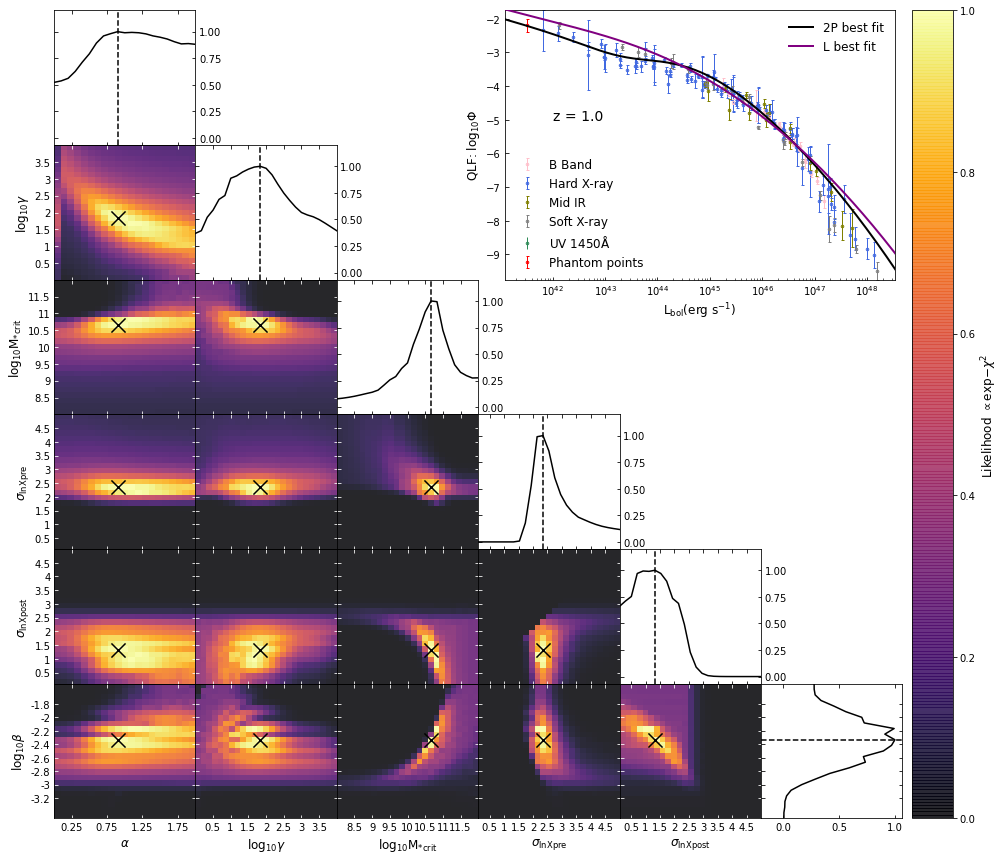

In [8]:
plt.close('all')


fig = plt.figure(figsize=(15,12))
gs = gridspec.GridSpec(6, 6)

likelihood = np.exp(-reduced_chi2)

axj = [0,1,2,3,4,0,1,2,3,0,1,2,0,1,0]
axi = [5,5,5,5,5,4,4,4,4,3,3,3,2,2,1]
axes_l = []

extents = [\
           [slope_low[0], slope_low [-1], norm_of_local[-1], norm_of_local[0]],\
           [norm_from_local[0], norm_from_local[-1], norm_of_local[-1], norm_of_local[0]],\
           [transition[0], transition[-1], norm_of_local[-1], norm_of_local[0]],\
           [siglnX1[0], siglnX1[-1], norm_of_local[-1], norm_of_local[0]],\
           [siglnX2[0], siglnX2[-1], norm_of_local[-1], norm_of_local[0]],\
           [slope_low[0], slope_low[-1], siglnX2[-1], siglnX2[0]],\
           [norm_from_local[0], norm_from_local[-1], siglnX2[-1], siglnX2[0]],\
           [transition[0], transition[-1], siglnX2[-1], siglnX2[0]],\
           [siglnX1[0], siglnX1[-1], siglnX2[-1], siglnX2[0]],\
           [slope_low[0], slope_low[-1], siglnX1[-1], siglnX1[0]],\
           [norm_from_local[0], norm_from_local[-1], siglnX1[-1], siglnX1[0]],\
           [transition[0], transition[-1], siglnX1[-1], siglnX1[0]],\
           [slope_low[0], slope_low[-1], transition[-1], transition[0]],\
           [norm_from_local[0], norm_from_local[-1], transition[-1], transition[0]],\
           [slope_low[0], slope_low[-1], norm_from_local[-1], norm_from_local[0]]\
          ]

bl = ''  
slopel = r'$\alpha$'
norml = r'$\log_{10}\gamma$'
prel = r'$\sigma_{\ln{\rmXpre}}$'
postl = r'$\sigma_{\ln{\rmXpost}}$'
critl = r'$\log_{10}\rmM_{*crit}$'
locall = r'$\log_{10}\beta$'
xlabels = [slopel, norml, critl, prel, postl, bl, bl, bl, bl, bl, bl, bl, bl, bl, bl]
ylabels = [locall, bl, bl, bl, bl, postl, bl, bl, bl, prel, bl, bl, critl, bl, norml]
slopet = [ 0.25, 0.75, 1.25, 1.75]
normt = [0.5, 1, 1.5, 2, 2.5, 3, 3.5]
pret = [0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5]
postt = [0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5]
localt = [-3.2, -3, -2.8, -2.6, -2.4, -2.2, -2, -1.8]
critt = [8.5, 9, 9.5, 10, 10.5, 11, 11.5]
xticks = [slopet, normt, critt, pret, postt, slopet, normt, critt, pret, slopet, normt, critt, slopet, normt, slopet]
yticks = [localt, localt, localt, localt, localt, postt, postt, postt, postt, pret, pret, pret, critt, critt, normt] 
indices = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14]
best_fits = [[alpha_fit,beta_fit],[gamma_fit,beta_fit],[crit_fit,beta_fit],[pre_fit,beta_fit],[post_fit,beta_fit],\
            [alpha_fit,post_fit],[gamma_fit,post_fit],[crit_fit,post_fit],[pre_fit,post_fit],\
            [alpha_fit,pre_fit],[gamma_fit,pre_fit],[crit_fit,pre_fit],\
            [alpha_fit,crit_fit],[gamma_fit,crit_fit],\
            [alpha_fit,gamma_fit]]
for ind, i, j in zip(indices, axi, axj):   
        
    ### set up axis and label info
    ylabel = ylabels[ind]
    xlabel = xlabels[ind]
    extent = extents[ind]

                     
    ax = fig.add_subplot(gs[i, j])
    axes_l += [ax]
    ax.set_xlabel(xlabel,fontsize=12)
    ax.set_ylabel(ylabel,fontsize=12)
    ax.axis([extents[ind][0],extents[ind][1],extents[ind][3],extents[ind][2]])

    plt.setp(ax, xticks=xticks[ind],yticks=yticks[ind])
    ax.set_xticklabels([str(i) for i in xticks[ind]])
    ax.set_yticklabels([str(i) for i in yticks[ind]])
        
    chi23d = likelihood
    if ind == 0:
        chi2_proj = np.zeros(chi23d[:,0,:,0,0,0].shape)
        for i in range(len(chi23d[:,0,0,0,0,0])):
            for j in range(len(chi23d[0,0,:,0,0,0])):
                chi2_proj[i, j] = np.amax(chi23d[i, :, j, :, :,:])
        grid2d = chi2_proj

    elif ind == 1:
        chi2_proj = np.zeros(chi23d[:,:,0,0,0,0].shape)
        for i in range(len(chi23d[:,0,0,0,0,0])):
            for j in range(len(chi23d[0,:,0,0,0,0])):
                chi2_proj[i, j] = np.amax(chi23d[i, j, :, :, :, :])
        grid2d = chi2_proj

    elif ind == 2:
        chi2_proj = np.zeros(chi23d[:,0,0,0,0,:].shape)
        for i in range(len(chi23d[:,0,0,0,0,0])):
            for j in range(len(chi23d[0,0,0,0,0,:])):
                chi2_proj[i, j] = np.amax(chi23d[i, :, :, :, :, j])
        grid2d = chi2_proj

    elif ind == 3:
        chi2_proj = np.zeros(chi23d[:,0,0,0,:,0].shape)
        for i in range(len(chi23d[:,0,0,0,0,0])):
            for j in range(len(chi23d[0,0,0,0,:,0])):
                chi2_proj[i, j] = np.amax(chi23d[i, :, :, :, j, :])
        grid2d = chi2_proj

    elif ind == 4:
        chi2_proj = np.zeros(chi23d[:,0,0,:,0,0].shape)
        for i in range(len(chi23d[:,0,0,0,0,0])):
            for j in range(len(chi23d[0,0,0,:,0,0])):
                chi2_proj[i, j] = np.amax(chi23d[i, :, :, j, :, :])
        grid2d = chi2_proj

    elif ind == 5:
        chi2_proj = np.zeros(chi23d[0,0,:,:,0,0].shape)
        for i in range(len(chi23d[0,0,:,0,0,0])):
            for j in range(len(chi23d[0,0,0,:,0,0])):
                chi2_proj[i, j] = np.amax(chi23d[:, :, i, j, :, :])
        grid2d = chi2_proj.T

    elif ind == 6:
        chi2_proj = np.zeros(chi23d[0,:,0,:,0,0].shape)
        for i in range(len(chi23d[0,:,0,0,0,0])):
            for j in range(len(chi23d[0,0,0,:,0,0])):
                chi2_proj[i, j] = np.amax(chi23d[:, i, :, j, :, :])
        grid2d = chi2_proj.T

    elif ind == 7:
        chi2_proj = np.zeros(chi23d[0,0,0,:,0,:].shape)
        for i in range(len(chi23d[0,0,0,:,0,0])):
            for j in range(len(chi23d[0,0,0,0,0,:])):
                chi2_proj[i, j] = np.amax(chi23d[:, :, :, i, :, j])
        grid2d = chi2_proj

    elif ind == 8:
        chi2_proj = np.zeros(chi23d[0,0,0,:,:,0].shape)
        for i in range(len(chi23d[0,0,0,:,0,0])):
            for j in range(len(chi23d[0,0,0,0,:,0])):
                chi2_proj[i, j] = np.amax(chi23d[:, :, :, i, j, :])
        grid2d = chi2_proj

    elif ind == 9:
        chi2_proj = np.zeros(chi23d[0,0,:,0,:,0].shape)
        for i in range(len(chi23d[0,0,:,0,0,0])):
            for j in range(len(chi23d[0,0,0,0,:,0])):
                chi2_proj[i, j] = np.amax(chi23d[:, :, i, :, j, :])
        grid2d = chi2_proj.T

    elif ind == 10:
        chi2_proj = np.zeros(chi23d[0,:,0,0,:,0].shape)
        for i in range(len(chi23d[0,:,0,0,0,0])):
            for j in range(len(chi23d[0,0,0,0,:,0])):
                chi2_proj[i, j] = np.amax(chi23d[:, i, :, :, j, :])
        grid2d = chi2_proj.T

    elif ind == 11:
        chi2_proj = np.zeros(chi23d[0,0,0,0,:,:].shape)
        for i in range(len(chi23d[0,0,0,0,:,0])):
            for j in range(len(chi23d[0,0,0,0,0,:])):
                chi2_proj[i, j] = np.amax(chi23d[:, :, :, :, i, j])
        grid2d = chi2_proj

    elif ind == 12:
        chi2_proj = np.zeros(chi23d[0,0,:,0,0,:].shape)
        for i in range(len(chi23d[0,0,:,0,0,0])):
            for j in range(len(chi23d[0,0,0,0,0,:])):
                chi2_proj[i, j] = np.amax(chi23d[:, :, i, :, :, j])
        grid2d = chi2_proj.T

    elif ind == 13:
        chi2_proj = np.zeros(chi23d[0,:,0,0,0,:].shape)
        for i in range(len(chi23d[0,:,0,0,0,0])):
            for j in range(len(chi23d[0,0,0,0,0,:])):
                chi2_proj[i, j] = np.amax(chi23d[:, i, :, :, :, j])
        grid2d = chi2_proj.T

    elif ind == 14: 
        chi2_proj = np.zeros(chi23d[0,:,:,0,0,0].shape)
        for i in range(len(chi23d[0,:,0,0,0,0])):
            for j in range(len(chi23d[0,0,:,0,0,0])):
                chi2_proj[i, j] = np.amax(chi23d[:, i, j, :, :, :])
        grid2d = chi2_proj
     
    vmax = 1
    norm = colors.Normalize(vmin = 0, vmax = vmax)

    cmap = matplotlib.cm.get_cmap('inferno')
    img = ax.imshow(grid2d/np.amax(grid2d), cmap = cmap, interpolation = 'nearest', aspect='auto', extent = extent, norm=norm, alpha=0.85)
    ax.scatter(best_fits[ind][0], best_fits[ind][1], marker = 'x', c='k', s=200)
    ax.tick_params(axis='both', direction='in',top=True,right=True,color='white')

plt.setp(axes_l[5].get_xticklabels(), visible=False)
plt.setp(axes_l[6].get_xticklabels(), visible=False)
plt.setp(axes_l[7].get_xticklabels(), visible=False)
plt.setp(axes_l[8].get_xticklabels(), visible=False)
plt.setp(axes_l[9].get_xticklabels(), visible=False)
plt.setp(axes_l[10].get_xticklabels(), visible=False)
plt.setp(axes_l[11].get_xticklabels(), visible=False)
plt.setp(axes_l[12].get_xticklabels(), visible=False)
plt.setp(axes_l[13].get_xticklabels(), visible=False)
plt.setp(axes_l[14].get_xticklabels(), visible=False)

plt.setp(axes_l[1].get_yticklabels(), visible=False)
plt.setp(axes_l[2].get_yticklabels(), visible=False)
plt.setp(axes_l[3].get_yticklabels(), visible=False)
plt.setp(axes_l[4].get_yticklabels(), visible=False)
plt.setp(axes_l[6].get_yticklabels(), visible=False)
plt.setp(axes_l[7].get_yticklabels(), visible=False)
plt.setp(axes_l[8].get_yticklabels(), visible=False)
plt.setp(axes_l[10].get_yticklabels(), visible=False)
plt.setp(axes_l[11].get_yticklabels(), visible=False)
plt.setp(axes_l[13].get_yticklabels(), visible=False)


axj = [0,1,2,3,4,5]
axi = [0,1,2,3,4,5]
ranges = [slope_low, norm_from_local, transition, siglnX1, siglnX2, norm_of_local]
share = [axes_l[0], axes_l[1], axes_l[2], axes_l[3], axes_l[4], axes_l[0]]
best_fits = [alpha_fit, gamma_fit, crit_fit, pre_fit, post_fit, beta_fit]
inds = [0,1,2,3,4,5]

for ind, i, j in zip(inds, axi, axj):    
    if ind == 0:
        ax = fig.add_subplot(gs[i, j],sharex = share[ind])
        axes_l += [ax]
        proj = np.zeros(chi23d[0,0,:,0,0,0].shape)
        for k in range(len(chi23d[0,0,:,0,0,0])):
            proj[k] = np.amax(chi23d[:,:,k,:,:,:])
    elif ind == 1:
        ax = fig.add_subplot(gs[i, j],sharex = share[ind])
        axes_l += [ax]
        proj = np.zeros(chi23d[0,:,0,0,0,0].shape)
        for k in range(len(chi23d[0,:,0,0,0,0])):
            proj[k] = np.amax(chi23d[:,k,:,:,:,:])
    elif ind == 2:
        ax = fig.add_subplot(gs[i, j],sharex = share[ind])
        axes_l += [ax]
        proj = np.zeros(chi23d[0,0,0,0,0,:].shape)
        for k in range(len(chi23d[0,0,0,0,0,:])):
            proj[k] = np.amax(chi23d[:,:,:,:,:,k])
    elif ind == 3:
        ax = fig.add_subplot(gs[i, j],sharex = share[ind])
        axes_l += [ax]
        proj = np.zeros(chi23d[0,0,0,0,:,0].shape)
        for k in range(len(chi23d[0,0,0,0,:,0])):
            proj[k] = np.amax(chi23d[:,:,:,:,k,:])
    elif ind == 4:
        ax = fig.add_subplot(gs[i, j],sharex = share[ind])
        axes_l += [ax]
        proj = np.zeros(chi23d[0,0,0,:,0,0].shape)
        for k in range(len(chi23d[0,0,0,:,0,0])):
            proj[k] = np.amax(chi23d[:,:,:,k,:,:])
    elif ind == 5:
        ax = fig.add_subplot(gs[i, j],sharey = share[ind])
        axes_l += [ax]
        proj = np.zeros(chi23d[:,0,0,0,0,0].shape)
        for k in range(len(chi23d[:,0,0,0,0,0])):
            proj[k] = np.amax(chi23d[k,:,:,:,:,:])
    
    proj = proj/max(proj)
    if ind != 5:
        ax.plot(ranges[ind], proj, c='k')
        ax.set_ylim([0-max(proj)/15,max(proj)+max(proj)/5])
        ax.yaxis.tick_right()
        ax.yaxis.set_label_position("right")
        ax.tick_params(axis='both', direction='in',top=True,right=True, left=True,color='k')
        plt.setp(ax.get_xticklabels(), visible=False)
        ax.axvline(best_fits[ind], c='k', ls='dashed')
    else:
        ax.plot(proj, ranges[ind],c='k')
        ax.tick_params(axis='both', direction='in',right=True, top=True, bottom=True,color='k')
        ax.set_xlim([0-max(proj)/5,max(proj)+max(proj)/15])
        plt.setp(ax.get_yticklabels(), visible=False)
        ax.axhline(best_fits[ind], c='k', ls='dashed')

        

gs2 = gridspec.GridSpec(6, 3)
gs2.update(left=0.55, right=0.98)
ax = fig.add_subplot(gs2[0:2,:])
axes_l.append(ax)

bins = 0.0005
z = 1.0
lums = np.linspace(5,18,200)
lumsp = 10**lums*3.8e33

qlf = QLF(z, bins)
qlf.get_Mbh(crit_fit, alpha_fit, gamma_fit, norm_local = 11+beta_fit)
qlf.get_dNdlnL(lums, [pre_fit, post_fit])
ax.plot(lumsp, np.log10(qlf.dNdlogL), c='k', label = '2P best fit', lw=2, zorder=10)

qlf = get_QLF(lums, z, fixed_L)
ax.plot(lumsp, np.log10(qlf.dNdlogL), c='purple', label = r'L best fit', lw=2, zorder=10)


objs, labels = plot_obs(ax, phantom = True)

ax.axis([10**7.5*3.8e33,10**14.95*3.8e33,-9.75,-1.75])
ax.set_xlabel(r'$\rmL_{bol} (erg\ s^{-1})$', fontsize=12)
ax.set_ylabel(r'QLF: $\log_{10} \Phi$', fontsize =12)
ax.text(10**42,-5,'z = '+str(z), fontsize = 14)
ax.set_xscale('log')
ax.tick_params(axis='both', which='both', labelsize=10, direction='in')
legend = ax.legend(fontsize=12, loc='upper right', framealpha=0)
legendB = ax.legend(handles = objs, labels=labels, fontsize = 12, loc='lower left', framealpha=0)
ax.add_artist(legend)

plt.tight_layout()
plt.subplots_adjust(wspace=0, hspace=0)
cbar = plt.colorbar(img, pad = 0.01, ax = axes_l).set_label(label=r'Likelihood $\propto \exp{-\chi ^2}$ ',size=12)

        
plt.savefig('paper_plots/bivariate-likelihood-fixedz-6param.pdf')

## Alpha = 1 fits

In [6]:
redshifts = [0.5, 1.0, 2.0, 3.0, 4.0]
filename = '../ceph/QLF_proj/output/chi2_2P'

print('Generating alpha=1 null grid.')
null = get_null_a1(filename+'_z'+str(redshifts[0])+'.h5py')
print('done')


bulge = False
print('Combining grids.')
for z in redshifts:
    f = h5py.File(filename+'_z'+str(z)+'.h5py', "r") 
    if bulge:
        transition = f['logMb0'][:]
    else:
        transition = f['logMstar0'][:]
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    slope_low = f['slope_low'][:]
    norm_from_local = f['norm_from_local'][:]
    norm_of_local = f['norm_of_local'][:]
    if z == redshifts[0]:
        chi2_grid = f['chi2_grid'][:].T
    else:
        chi2_grid += f['chi2_grid'][:].T
    f.close()

reduced_chi2 = chi2_grid/(totpoints-5)
print('Setting null points.')
reduced_chi2[null] = 1e6

print('Finding best fit values.')
minval = np.amin(reduced_chi2)
minind = np.where(reduced_chi2 == minval)

print('chi2 reduced =', minval)

beta_fit = norm_of_local[minind[0][0]] 
gamma_fit = norm_from_local[minind[1][0]]
alpha_fit = slope_low[minind[2][0]]
post_fit = siglnX2[minind[3][0]]
pre_fit = siglnX1[minind[4][0]]
crit_fit = transition[minind[5][0]] 

Generating alpha=1 null grid.
done
Combining grids.
Setting null points.
Finding best fit values.
chi2 reduced = 4.048436368204634


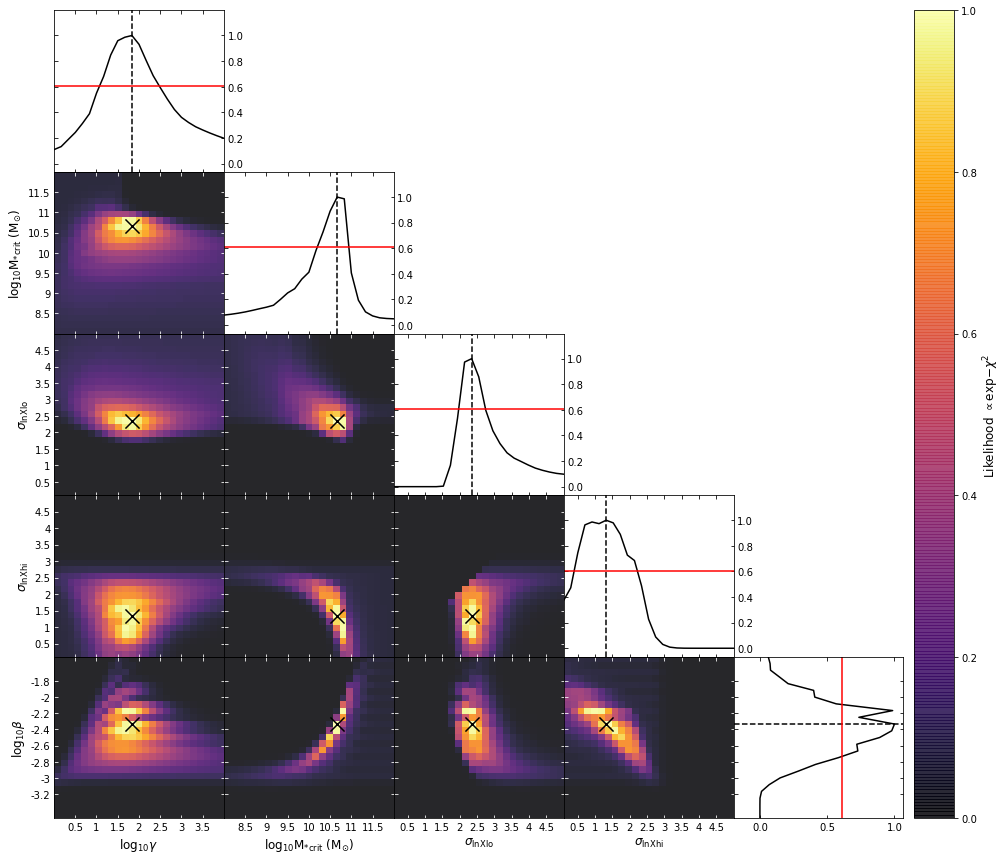

In [7]:
plt.close('all')


fig = plt.figure(figsize=(15,12))
gs = gridspec.GridSpec(5, 5)

likelihood = np.exp(-reduced_chi2)

axj = [0,1,2,3,0,1,2,0,1,0]
axi = [4,4,4,4,3,3,3,2,2,1]
axes_l = []

extents = [[norm_from_local[0], norm_from_local[-1], norm_of_local[-1], norm_of_local[0]],\
           [transition[0], transition[-1], norm_of_local[-1], norm_of_local[0]],\
           [siglnX1[0], siglnX1[-1], norm_of_local[-1], norm_of_local[0]],\
           [siglnX2[0], siglnX2[-1], norm_of_local[-1], norm_of_local[0]],\
           [norm_from_local[0], norm_from_local[-1], siglnX2[-1], siglnX2[0]],\
           [transition[0], transition[-1], siglnX2[-1], siglnX2[0]],\
           [siglnX1[0], siglnX1[-1], siglnX2[-1], siglnX2[0]],\
           [norm_from_local[0], norm_from_local[-1], siglnX1[-1], siglnX1[0]],\
           [transition[0], transition[-1], siglnX1[-1], siglnX1[0]],\
           [norm_from_local[0], norm_from_local[-1], transition[-1], transition[0]],\
          ]

bl = ''  
norml = r'$\log_{10}\gamma$'
prel = r'$\sigma_{\ln{\rmXlo}}$'
postl = r'$\sigma_{\ln{\rmXhi}}$'
critl = r'$\log_{10}\rmM_{*crit}$ $\rm(M_{\odot})$'
locall = r'$\log_{10}\beta$'
xlabels = [norml, critl, prel, postl, bl, bl, bl, bl, bl, bl]
ylabels = [locall, bl, bl, bl, postl, bl, bl, prel, bl, critl]
slopet = [ 0.5, 1, 1.5, 2, 2.5, 3, 3.5]
normt = [0.5, 1, 1.5, 2, 2.5, 3, 3.5]
pret = [0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5]
postt = [0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5]
localt = [-3.2, -3, -2.8, -2.6, -2.4, -2.2, -2, -1.8]
critt = [8.5, 9, 9.5, 10, 10.5, 11, 11.5]
xticks = [normt, critt, pret, postt, normt, critt, pret,normt, critt, normt]
yticks = [localt, localt, localt, localt, postt, postt, postt, pret, pret, critt] 
indices = [0,1,2,3,4,5,6,7,8,9]
best_fits = [[gamma_fit,beta_fit],[crit_fit,beta_fit],[pre_fit,beta_fit],[post_fit,beta_fit],\
            [gamma_fit,post_fit],[crit_fit,post_fit],[pre_fit,post_fit],\
            [gamma_fit,pre_fit],[crit_fit,pre_fit],\
            [gamma_fit,crit_fit]]
for ind, i, j in zip(indices, axi, axj):   
        
    ### set up axis and label info
    ylabel = ylabels[ind]
    xlabel = xlabels[ind]
    extent = extents[ind]

                     
    ax = fig.add_subplot(gs[i, j])
    axes_l += [ax]
    ax.set_xlabel(xlabel,fontsize=12)
    ax.set_ylabel(ylabel,fontsize=12)
    ax.axis([extents[ind][0],extents[ind][1],extents[ind][3],extents[ind][2]])

    plt.setp(ax, xticks=xticks[ind],yticks=yticks[ind])
    ax.set_xticklabels([str(i) for i in xticks[ind]])
    ax.set_yticklabels([str(i) for i in yticks[ind]])
        
    chi23d = likelihood
    if ind == 0:
        chi2_proj = np.zeros(chi23d[:,:,0,0,0,0].shape)
        for i in range(len(chi23d[:,0,0,0,0,0])):
            for j in range(len(chi23d[0,:,0,0,0,0])):
                chi2_proj[i, j] = np.amax(chi23d[i, j, :, :, :, :])
        grid2d = chi2_proj

    elif ind == 1:
        chi2_proj = np.zeros(chi23d[:,0,0,0,0,:].shape)
        for i in range(len(chi23d[:,0,0,0,0,0])):
            for j in range(len(chi23d[0,0,0,0,0,:])):
                chi2_proj[i, j] = np.amax(chi23d[i, :, :, :, :, j])
        grid2d = chi2_proj

    elif ind == 2:
        chi2_proj = np.zeros(chi23d[:,0,0,0,:,0].shape)
        for i in range(len(chi23d[:,0,0,0,0,0])):
            for j in range(len(chi23d[0,0,0,0,:,0])):
                chi2_proj[i, j] = np.amax(chi23d[i, :, :, :, j, :])
        grid2d = chi2_proj

    elif ind == 3:
        chi2_proj = np.zeros(chi23d[:,0,0,:,0,0].shape)
        for i in range(len(chi23d[:,0,0,0,0,0])):
            for j in range(len(chi23d[0,0,0,:,0,0])):
                chi2_proj[i, j] = np.amax(chi23d[i, :, :, j, :, :])
        grid2d = chi2_proj

    elif ind == 4:
        chi2_proj = np.zeros(chi23d[0,:,0,:,0,0].shape)
        for i in range(len(chi23d[0,:,0,0,0,0])):
            for j in range(len(chi23d[0,0,0,:,0,0])):
                chi2_proj[i, j] = np.amax(chi23d[:, i, :, j, :, :])
        grid2d = chi2_proj.T

    elif ind == 5:
        chi2_proj = np.zeros(chi23d[0,0,0,:,0,:].shape)
        for i in range(len(chi23d[0,0,0,:,0,0])):
            for j in range(len(chi23d[0,0,0,0,0,:])):
                chi2_proj[i, j] = np.amax(chi23d[:, :, :, i, :, j])
        grid2d = chi2_proj

    elif ind == 6:
        chi2_proj = np.zeros(chi23d[0,0,0,:,:,0].shape)
        for i in range(len(chi23d[0,0,0,:,0,0])):
            for j in range(len(chi23d[0,0,0,0,:,0])):
                chi2_proj[i, j] = np.amax(chi23d[:, :, :, i, j, :])
        grid2d = chi2_proj

    elif ind == 7:
        chi2_proj = np.zeros(chi23d[0,:,0,0,:,0].shape)
        for i in range(len(chi23d[0,:,0,0,0,0])):
            for j in range(len(chi23d[0,0,0,0,:,0])):
                chi2_proj[i, j] = np.amax(chi23d[:, i, :, :, j, :])
        grid2d = chi2_proj.T

    elif ind == 8:
        chi2_proj = np.zeros(chi23d[0,0,0,0,:,:].shape)
        for i in range(len(chi23d[0,0,0,0,:,0])):
            for j in range(len(chi23d[0,0,0,0,0,:])):
                chi2_proj[i, j] = np.amax(chi23d[:, :, :, :, i, j])
        grid2d = chi2_proj


    elif ind == 9:
        chi2_proj = np.zeros(chi23d[0,:,0,0,0,:].shape)
        for i in range(len(chi23d[0,:,0,0,0,0])):
            for j in range(len(chi23d[0,0,0,0,0,:])):
                chi2_proj[i, j] = np.amax(chi23d[:, i, :, :, :, j])
        grid2d = chi2_proj.T
     
    vmax = 1
    norm = colors.Normalize(vmin = 0, vmax = vmax)

    cmap = matplotlib.cm.get_cmap('inferno')
    img = ax.imshow(grid2d/np.amax(grid2d), cmap = cmap, interpolation = 'nearest', aspect='auto', extent = extent, norm=norm, alpha=0.85)
    ax.scatter(best_fits[ind][0], best_fits[ind][1], marker = 'x', c='k', s=200)
    ax.tick_params(axis='both', direction='in',top=True,right=True,color='white')

plt.setp(axes_l[5].get_xticklabels(), visible=False)
plt.setp(axes_l[6].get_xticklabels(), visible=False)
plt.setp(axes_l[7].get_xticklabels(), visible=False)
plt.setp(axes_l[8].get_xticklabels(), visible=False)
plt.setp(axes_l[9].get_xticklabels(), visible=False)
plt.setp(axes_l[4].get_xticklabels(), visible=False)

plt.setp(axes_l[1].get_yticklabels(), visible=False)
plt.setp(axes_l[2].get_yticklabels(), visible=False)
plt.setp(axes_l[3].get_yticklabels(), visible=False)
plt.setp(axes_l[5].get_yticklabels(), visible=False)
plt.setp(axes_l[6].get_yticklabels(), visible=False)
plt.setp(axes_l[8].get_yticklabels(), visible=False)


axj = [0,1,2,3,4]
axi = [0,1,2,3,4]
ranges = [norm_from_local, transition, siglnX1, siglnX2, norm_of_local]
share = [axes_l[0], axes_l[1], axes_l[2], axes_l[3], axes_l[0]]
best_fits = [gamma_fit, crit_fit, pre_fit, post_fit, beta_fit]
inds = [0,1,2,3,4]

for ind, i, j in zip(inds, axi, axj):    
    if ind == 0:
        ax = fig.add_subplot(gs[i, j],sharex = share[ind])
        axes_l += [ax]
        proj = np.zeros(chi23d[0,:,0,0,0,0].shape)
        for k in range(len(chi23d[0,:,0,0,0,0])):
            proj[k] = np.amax(chi23d[:,k,:,:,:,:])
    elif ind == 1:
        ax = fig.add_subplot(gs[i, j],sharex = share[ind])
        axes_l += [ax]
        proj = np.zeros(chi23d[0,0,0,0,0,:].shape)
        for k in range(len(chi23d[0,0,0,0,0,:])):
            proj[k] = np.amax(chi23d[:,:,:,:,:,k])
    elif ind == 2:
        ax = fig.add_subplot(gs[i, j],sharex = share[ind])
        axes_l += [ax]
        proj = np.zeros(chi23d[0,0,0,0,:,0].shape)
        for k in range(len(chi23d[0,0,0,0,:,0])):
            proj[k] = np.amax(chi23d[:,:,:,:,k,:])
    elif ind == 3:
        ax = fig.add_subplot(gs[i, j],sharex = share[ind])
        axes_l += [ax]
        proj = np.zeros(chi23d[0,0,0,:,0,0].shape)
        for k in range(len(chi23d[0,0,0,:,0,0])):
            proj[k] = np.amax(chi23d[:,:,:,k,:,:])
    elif ind == 4:
        ax = fig.add_subplot(gs[i, j],sharey = share[ind])
        axes_l += [ax]
        proj = np.zeros(chi23d[:,0,0,0,0,0].shape)
        for k in range(len(chi23d[:,0,0,0,0,0])):
            proj[k] = np.amax(chi23d[k,:,:,:,:,:])
    
    proj = proj/max(proj)
    if ind != 4:
        ax.plot(ranges[ind], proj, c='k')
        ax.set_ylim([0-max(proj)/15.1,max(proj)+max(proj)/5.1])
        ax.yaxis.tick_right()
        ax.yaxis.set_label_position("right")
        ax.tick_params(axis='both', direction='in',top=True,right=True, left=True,color='k')
        plt.setp(ax.get_xticklabels(), visible=False)
        ax.axvline(best_fits[ind], c='k', ls='dashed')
        ax.axhline(np.exp(-0.5), c='r')
    else:
        ax.plot(proj, ranges[ind],c='k')
        ax.tick_params(axis='both', direction='in',right=True, top=True, bottom=True,color='k')
        ax.set_xlim([0-max(proj)/5.1,max(proj)+max(proj)/15.1])
        plt.setp(ax.get_yticklabels(), visible=False)
        ax.axhline(best_fits[ind], c='k', ls='dashed')
        ax.axvline(np.exp(-0.5), c='r')

plt.tight_layout()
plt.subplots_adjust(wspace=0, hspace=0)
cbar = plt.colorbar(img, pad = 0.01, ax = axes_l).set_label(label=r'Likelihood $\propto \exp{-\chi ^2}$ ',size=12)

        
plt.savefig('paper_plots/bivariate-likelihood-fixedz_w1sigma.pdf')

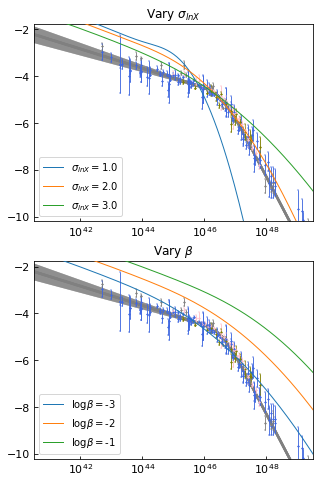

In [14]:
def plot_obs(ax, phantom = False):
    objs = []
    labels = []
    colors = {'B-Band':'pink', 'UV-1450A':'seagreen', 'Hard-X':'royalblue', 'Soft-X':'grey', 'Mid-IR':'olive'}
    cleanlabel = {'B-Band':'B Band', 'UV-1450A':r'UV 1450$\rm\AA$', 'Hard-X':'Hard X-ray', 'Soft-X':'Soft X-ray', 'Mid-IR':'Mid IR'}

    fobs = h5py.File("SHEN_obs_collect.h5py", "r")
    for band in fobs["z="+str(z)]:
        index = "z="+str(z)+"/"+band
        x = fobs[index]['x'][:]
        y = fobs[index]['y'][:]
        xerr = fobs[index]['xerr'][:]
        yerr = fobs[index]['yerr'][:]
        xerrcor = np.zeros((2,len(xerr)))
        xerrcor[1,:] = 10**(x + xerr) - 10**x
        xerrcor[0,:] = 10**x - 10**(x - xerr)

        b = ax.errorbar(10**x, y, yerr = yerr, c=colors[band], fmt = 'o', fillstyle='none', capsize=0.75, ms=.75, lw=0.5, capthick=0.25, zorder=2, alpha = 1)
        objs.append(b)
        labels.append(cleanlabel[band])
    fobs.close()
    
    if phantom:
        xtot = []
        ya = []
        yaerr = []
        fobs = h5py.File("SHEN_obs_collect.h5py", "r")
        for band in fobs["z="+str(z)]:
            index = "z="+str(z)+"/"+band
            xtot.extend(fobs[index]['x'][:]) ##log10 of bolometric L in erg/s
            ya.extend(fobs[index]['y'][:]) ##log10 of QLF
            yaerr.extend(fobs[index]['yerr'][:]) ##error on that
        fobs.close()

        xobscut = min(np.asarray(xtot))
        xphan = np.linspace(40, 44, 9)
        if round(xobscut) < xobscut:
            xphan = xphan[xphan <= round(xobscut)]
        else:
            xphan = xphan[xphan < round(xobscut)]
        yphan, yphanerr, _, _, _ = Shen_fit_uncer(z, np.log10(10**xphan/3.8e33))

        p = ax.errorbar(10**xphan, yphan, yerr = yphanerr, c='r', fmt = 'o', fillstyle='none', capsize=1, ms=1.0, lw=0.5, zorder=2)
        objs.append(p)
        labels.append('Extrapolated points')

    return objs, labels

def plot_SHEN(ax):
    dens, stanave, stanab, stanb, _ = Shen_fit_uncer(z, lums)
    sqlf, = ax.plot(lumsp, dens, lw=2.5, linestyle='solid', c='gray', zorder=1)
    ax.fill_between(lumsp, dens + stanave, dens - stanave, color = 'gray', alpha = 0.5, zorder = 0, lw = 0)
    label = 'Shen+20 fit'
    
    return sqlf, label

def format_QLF_ax(ax):
    ax.tick_params(axis='both', which='both', labelsize=11, direction='in')
    ax.tick_params(axis='both', which='both', labelsize=11, direction='in')
    ax.axis([10**40.5,10**49.5,-10.2,-1.75])
    ax.set_xscale('log')
    
def get_QLF(lums, z, params, postsig, postnorm):
    
    Mscrit = params['Transition point']
    preslope = params['Pre-disk slope']
    Mbhnorm = params['Pre-disk normalization']
#     postnorm = params['Post-disk normalization']
#     presig = params['Pre-disk sigma']
#     postsig = params['Post-disk sigma']
    
    qlf = QLF(z, 0.005)
    qlf.get_Mbh(Mscrit, preslope, Mbhnorm, approx_local=True, norm_local = 11+postnorm)
    qlf.get_dNdlnL(lums, [postsig, postsig])
    
    return qlf
    
fig = plt.figure(figsize=(5,8))
gs = gridspec.GridSpec(2, 1)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0])
    
z = 2.0

lums = np.linspace(6,16,200)
lumsp = 10**lums*3.8e33

#### L vary all

for sig in [1.0, 2.0, 3.0]:
    qlf = get_QLF(lums, z, varied_L[str(z)], sig, -2.7)
    ax1.plot(lumsp, np.log10(qlf.dNdlogL), lw=1, zorder=10, label = r'$\sigma_{lnX} = $'+str(sig))
    format_QLF_ax(ax1)
    plot_SHEN(ax1)
    plot_obs(ax1)
    ax1.legend()
    ax1.set_title(r'Vary $\sigma_{lnX}$')
    
for norm in [-3, -2, -1]:
    qlf = get_QLF(lums, z, varied_L[str(z)], 2.7, norm)
    ax2.plot(lumsp, np.log10(qlf.dNdlogL), lw=1, zorder=10, label = r'$\log \beta = $'+str(norm))
    format_QLF_ax(ax2)
    plot_SHEN(ax2)
    plot_obs(ax2)
    ax2.legend()
    ax2.set_title(r'Vary $\beta$')

(100, 1, 1, 100, 1, 1)
{'Mscrit': 3.0, 'presig': 4.0, 'postsig': 2.631010101010101, 'preslope': 1.0, 'Mbhnorm': 0.0, 'postnorm': -3.0}
{'Mscrit': 10.666666666666666, 'presig': 2.3458333333333337, 'postsig': 1.3250000000000002, 'preslope': 1.0, 'Mbhnorm': 1.83875, 'postnorm': -2.3333333333333335}
{'Mscrit': 10.666666666666666, 'presig': 2.3458333333333337, 'postsig': 1.3250000000000002, 'preslope': 0.9, 'Mbhnorm': 1.83875, 'postnorm': -2.3333333333333335}


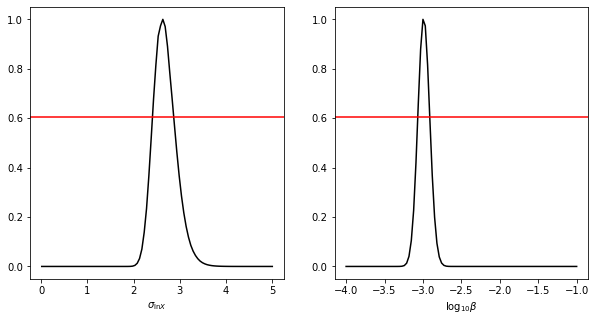

In [30]:
filename = '../ceph/QLF_proj/output/chi2_L'
for z in redshifts:
    f = h5py.File(filename+'_z'+str(z)+'.h5py', "r") 
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    slope_low = f['slope_low'][:]
    norm_from_local = f['norm_from_local'][:]
    norm_of_local = f['norm_of_local'][:]
    if z == redshifts[0]:
        chi2_grid = f['chi2_grid'][:].T
    else:
        chi2_grid += f['chi2_grid'][:].T
    f.close()

reduced_chi2 = chi2_grid/(totpoints-2)
chi23d = np.exp(-reduced_chi2)
print(np.shape(chi23d))

fig = plt.figure(figsize=(10,5))
gs = gridspec.GridSpec(1, 2)

    
ax = fig.add_subplot(gs[0, 0])
proj = np.zeros(chi23d[0,0,0,:,0,0].shape)
for k in range(len(chi23d[0,0,0,:,0,0])):
    proj[k] = np.amax(chi23d[:,:,:,k,:,:])
    
proj = proj/max(proj)
ax.plot(siglnX2, proj, c='k')
ax.axhline(np.exp(-0.5), c='r')
ax.set_xlabel(r'$\sigma_{\ln X}$')
    
ax = fig.add_subplot(gs[0, 1])
proj = np.zeros(chi23d[:,0,0,0,0,0].shape)
for k in range(len(chi23d[:,0,0,0,0,0])):
    proj[k] = np.amax(chi23d[k,:,:,:,:,:])
    
proj = proj/max(proj)
ax.plot(norm_of_local, proj, c='k')
ax.axhline(np.exp(-0.5), c='r')
ax.set_xlabel(r'$\log_{10}\beta$')

print(fixed_paramsL)
print(fixed_paramsF_a1)
print(fixed_paramsF)